# 1) Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

import folium
from folium import LayerControl

In [2]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

# 2) Nettoyage et conversion de float à int

In [3]:
def clean_df(df: pd.DataFrame):
    # On supprime les colonnes ayant plus de 80% de valeurs manquantes
    valeurs_manquantes = df.isna().sum()/df.shape[0]
    valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
    df_filtered = df.drop(valeurs_manquantes_list, axis = 1)
    # On supprime les colonnes "n6" pour ne laisser que les "n7" qui paraissent plus judicieuses (basées sur un plus grand nombre de bien)
    column_n6 = [ column for column in df_filtered.columns if "n6" in column]
    df_filtered = df_filtered.drop(column_n6, axis = 1)
    if 'typedebien' in df_filtered.columns:
        df_filtered = df_filtered[df_filtered['typedebien'] != 'l']
        df_filtered['typedebien'] = df_filtered['typedebien'].replace({'an': 'a', 'mn': 'm'})

    # On transform en Int des colonnes déclarées en float mais n'ayant que des int
    valeurs_manq_resid_quanti = [col for  col in df_filtered.select_dtypes(exclude='object').columns if df_filtered[col].isna().sum() > 0]    
    col_float = df_filtered[valeurs_manq_resid_quanti].select_dtypes(include='float64').columns
    for col in col_float:
        array_col = np.array(df_filtered[df_filtered[col].notna()][col]) 
        array_col_round = np.round(array_col)
        array_real_float = array_col[array_col != array_col_round]
        if len(array_real_float) == 0:
            df_filtered[col] = df_filtered[col].astype('Int64')
    # on transforme les colonnes quali n'ayant en fait que deux modalités
    if 'cave' in df_filtered.columns:
        df_filtered["cave"] = df_filtered["cave"].astype('Int64')
    if 'ascenseur' in df_filtered.columns:
        df_filtered["ascenseur"] = df_filtered["ascenseur"].astype('Int64')
    if 'logement_neuf' in df_filtered.columns:
        df_filtered["logement_neuf"] = df_filtered["logement_neuf"].replace({'n': False, 'o': True}).astype('Int64')

    return df_filtered

In [4]:
df_ventes = clean_df(df_ventes)
target = df_ventes['prix_bien']

# 3) Split train/test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_ventes.drop(columns=['prix_bien']),
    target,
    test_size=0.2,
    random_state=42
)

# 4) Transformer pour le remplissage (quali et quanti) du dataframe

In [6]:
class KNNImputerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, type_col="typedebien", lat_col="mapCoordonneesLatitude", lon_col="mapCoordonneesLongitude", pieces_col="nb_pieces", k=10):
        self.type_col = type_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.pieces_col = pieces_col
        self.k = k
        self.fitted = False
 
    def fit(self, X, y=None):
        self.df_train_ = X.copy()
        self.numeric_cols_ = X.select_dtypes(exclude="object").columns.tolist()
        self.default_mean_ = {col: X[col].mean() for col in self.numeric_cols_}
        self.imputer_ = KNNImputer()
        self.quali_cols_ = X.select_dtypes(include="object").columns.tolist()
        self.default_mode_ = {col: X[col].mode()[0] for col in self.quali_cols_}
        self.fitted = True
        
        return self
 
    def transform(self, X):
        if not(self.fitted):
            raise NotFittedError("This KNNImputerCustomed instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.")
        X = X.copy()
        # First we fill the numeric columns
        for col in self.numeric_cols_:
            if X[col].isna().sum() == 0:
                continue
            cols = [col, self.pieces_col, self.lat_col, self.lon_col]
            df_extract = X[[self.type_col] + cols]
            df_extract_train = self.df_train_ [[self.type_col] + cols]
            for typ in ["a", "m"]:
                subset = df_extract[df_extract[self.type_col] == typ][cols]
                if subset.shape[0] == 0:
                    continue
                apply_default = True
                subset_train = df_extract_train[df_extract_train[self.type_col] == typ][cols]
                if subset_train.shape[0] != 0:
                    self.imputer_.fit(subset_train)
                    imputed = self.imputer_.transform(subset)
                    if imputed.shape[1] == len(cols):
                        imputed_df = pd.DataFrame(imputed, columns=cols, index=subset.index)
                        apply_default = False
                if apply_default:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[subset.index, col] = self.default_mean_[col].astype("int64")
                    else:
                        X.loc[subset.index, col] = self.default_mean_[col]
                else:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[imputed_df.index, col] = imputed_df[col].round().astype("int64")
                    else:
                        X.loc[imputed_df.index, col] = imputed_df[col]

        #Secondly we fill the qualitative columns
        index_na = X[X[self.quali_cols_].isna().any(axis=1)].index
        for idx in index_na:
            lat = X.loc[idx, self.lat_col]
            lon = X.loc[idx, self.lon_col]
            nbp = X.loc[idx, self.pieces_col]
            typ = X.loc[idx, self.type_col]
            neighbours = self.df_train_[
                (self.df_train_[self.pieces_col] == nbp) &
                (self.df_train_[self.type_col] == typ)
            ]
            distances = (lat - neighbours[self.lat_col])**2 + (lon - neighbours[self.lon_col])**2
            for col in self.quali_cols_:
                if pd.isna(X.loc[idx, col]):
                    valid = neighbours[neighbours[col].notna()]
                    if valid.shape[0] > 0:
                        idx_neigh = distances[valid.index].sort_values().iloc[:self.k].index
                        X.loc[idx, col] = neighbours.loc[idx_neigh][col].mode()[0]
                    else:
                        X.loc[idx, col] = self.default_mode_[col]
        
        return X

In [7]:
knn_imputer_custom = KNNImputerCustom()
X_train = knn_imputer_custom.fit_transform(X_train)
X_test = knn_imputer_custom.transform(X_test)

# 5) Fonction de nettoyage des outiliers (IQR)

In [8]:
# Suppression de certains champs dont nous ne connaissons pas la définition
X_train.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)
X_test.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)

In [9]:
X_train_clean = X_train

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_train[col].quantile(0.1), 0)
    q3 = max(X_train[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_train[(X_train[col] < lower) | (X_train[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_train_clean = X_train_clean.drop(index_to_drop)

nb_rows_avant = X_train.shape[0]
nb_rows_apres = X_train_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_train = X_train_clean
y_train = y_train.loc[X_train.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 272  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  421.0  ( 105  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2850.0  ( 351  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 47  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 331  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 3  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 16  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 89  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  745.8  ( 13  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.595870000000005  ou  mapCoordonneesLatitude  >  49.07131999999999  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.43378  ou  mapCoordonneesLongitude  >  8.263480000000001  ( 0  rows)
Suppression des lignes où  nb_etages 

In [10]:
X_test_clean = X_test

numeric_cols = X_test.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_test[col].quantile(0.1), 0)
    q3 = max(X_test[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_test[(X_test[col] < lower) | (X_test[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_test_clean = X_test_clean.drop(index_to_drop)

nb_rows_avant = X_test.shape[0]
nb_rows_apres = X_test_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_test = X_test_clean
y_test = y_test.loc[X_test.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 85  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  430.0  ( 26  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2857.5868  ( 85  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 12  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 88  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 1  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 4  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 22  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  748.9800000000002  ( 3  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.59563  ou  mapCoordonneesLatitude  >  49.07168  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.445864  ou  mapCoordonneesLongitude  >  8.251978999999999  ( 0  rows)
Suppression des lignes où  nb_etages  <  0  ou

# 6) Normalisation des données GPS (fit sur train)

In [11]:
scaler_lat = StandardScaler()
scaler_lon = StandardScaler()

X_train['Latitude_scaled']  = scaler_lat.fit_transform(X_train[['mapCoordonneesLatitude']])
X_train['Longitude_scaled'] = scaler_lon.fit_transform(X_train[['mapCoordonneesLongitude']])

X_test['Latitude_scaled']  = scaler_lat.transform(X_test[['mapCoordonneesLatitude']])
X_test['Longitude_scaled'] = scaler_lon.transform(X_test[['mapCoordonneesLongitude']])

# 7) Target Encoding (fit sur train)

In [12]:
cols_te = ['INSEE_COM', 'typedebien_lite', 'nb_pieces']

mean_price_by_combo = (
    X_train.assign(prix_bien=y_train)
    .groupby(cols_te, as_index=False)['prix_bien']
    .mean()
    .rename(columns={'prix_bien': 'prix_bien_target_encoding'})
)
indexes_train = X_train.index
indexes_test = X_test.index
X_train = X_train.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_train)
X_test  = X_test.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_test)

X_test[['prix_bien_target_encoding']] = X_test[['prix_bien_target_encoding']].fillna(y_train.mean())

In [13]:
X_train.head(3)

,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,bain,dpeL,dpeC,mapCoordonneesLatitude,mapCoordonneesLongitude,annonce_exclusive,nb_etages,places_parking,cave,exposition,ges_class,annee_construction,nb_toilettes,ascenseur,nb_logements_copro,charges_copro,chauffage_energie,chauffage_systeme,chauffage_mode,categorie_annonceur,logement_neuf,typedebien_lite,date,INSEE_COM,IRIS,CODE_IRIS,TYP_IRIS_x,TYP_IRIS_y,GRD_QUART,UU2010,REG,DEP,prix_m2_vente,Latitude_scaled,Longitude_scaled,prix_bien_target_encoding
idannonce,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,pr,a,v,1,74,454.206,3,0,0,0,0,D,166.0,47.57683,7.52615,Oui,3,1,1,0,E,2005,1,1,12,1967.000,Fioul,Radiateur,Individuel,a,0,a,2021-01,68135,0,681350000,Z,Z,6813500,68403,44,68,2814.86,-1.268439,1.437389,258272.800000
ag680297-340567902,pr,m,v,0,122,1239.000,5,0,0,1,0,D,240.0,47.89687,7.22143,Oui,2,5,0,Nord-Ouest,B,1974,2,0,7,70.534,Gaz,Radiateur,Individuel,a,0,m,2022-04,68315,101,683150101,H,H,6831501,68401,44,68,3114.75,0.502046,-0.903823,306629.411765
hektor-girardi-pfastatt-2683,pr,m,v,0,167,560.000,5,0,0,0,0,F,400.0,47.88064,7.52845,Oui,2,3,0,0,G,1970,1,0,4,4.800,Électrique,Radiateur,Individuel,a,0,m,2021-04,68041,0,680410000,Z,Z,6804100,68000,44,68,772.46,0.412261,1.455061,298247.958333


# 8) Extraction année + OHE (fit sur train)

In [14]:
X_train['date'] = pd.to_datetime(X_train['date'])
X_test['date'] = pd.to_datetime(X_test['date'])

X_train['annee'] = X_train['date'].dt.year
X_test['annee'] = X_test['date'].dt.year

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
annee_train = ohe.fit_transform(X_train[['annee']])
annee_test  = ohe.transform(X_test[['annee']])

annee_cols = ohe.get_feature_names_out(['annee'])

X_train = pd.concat([X_train, pd.DataFrame(annee_train, columns=annee_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test,  pd.DataFrame(annee_test,  columns=annee_cols, index=X_test.index)], axis=1)

# 9) Parsing exposition / chauffage / DPE / GES

In [15]:
def parse_exposition(df):
    df = df.copy()
    df['exposition_clean'] = (
        df['exposition'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['expo_nord']  = df['exposition_clean'].str.contains(r'\bnord\b',  na=False).astype(int)
    df['expo_sud']   = df['exposition_clean'].str.contains(r'\bsud\b',   na=False).astype(int)
    df['expo_est']   = df['exposition_clean'].str.contains(r'\best\b',   na=False).astype(int)
    df['expo_ouest'] = df['exposition_clean'].str.contains(r'\bouest\b', na=False).astype(int)
    df['expo_inconnue'] = df['exposition_clean'].str.contains(r'0|nan', na=False).astype(int)
    return df

In [16]:
def parse_chauffage_systeme(df):
    df = df.copy()
    df['chauffage_systeme_clean'] = (
        df['chauffage_systeme'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauf_radiateur']  = df['chauffage_systeme_clean'].str.contains(r'\bradiateur\b', na=False).astype(int)
    df['chauf_sol']        = df['chauffage_systeme_clean'].str.contains(r'\bsol\b', na=False).astype(int)
    df['chauf_convecteur'] = df['chauffage_systeme_clean'].str.contains(r'\bconvecteur\b', na=False).astype(int)
    df['chauf_poele_bois'] = df['chauffage_systeme_clean'].str.contains(r'poêle|poele', na=False).astype(int)
    df['chauf_pac']        = df['chauffage_systeme_clean'].str.contains(r'pompe à chaleur|pac', na=False).astype(int)
    df['chauf_clim_rev']   = df['chauffage_systeme_clean'].str.contains(r'climatisation', na=False).astype(int)
    df['chauf_cheminee']   = df['chauffage_systeme_clean'].str.contains(r'cheminée|cheminee', na=False).astype(int)
    df['chauf_inconnu']    = df['chauffage_systeme_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [17]:
def parse_chauffage_energie(df):
    df = df.copy()
    df['chauffage_energie_clean'] = (
        df['chauffage_energie'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['energie_gaz']   = df['chauffage_energie_clean'].str.contains(r'\bgaz\b', na=False).astype(int)
    df['energie_elec']  = df['chauffage_energie_clean'].str.contains(r'électrique|electrique', na=False).astype(int)
    df['energie_fioul'] = df['chauffage_energie_clean'].str.contains(r'\bfioul\b', na=False).astype(int)
    df['energie_bois']  = df['chauffage_energie_clean'].str.contains(r'\bbois\b', na=False).astype(int)
    df['energie_inconnue'] = df['chauffage_energie_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [18]:
def parse_chauffage_mode(df):
    df = df.copy()
    df['chauffage_mode_clean'] = (
        df['chauffage_mode'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauffage_mode_individuel'] = df['chauffage_mode_clean'].str.contains(r'\bindividuel\b', na=False).astype(int)
    df['chauffage_mode_collectif']  = df['chauffage_mode_clean'].str.contains(r'\bcollectif\b', na=False).astype(int)
    df['chauffage_mode_central']    = df['chauffage_mode_clean'].str.contains(r'\bcentral\b', na=False).astype(int)
    df['chauffage_mode_inconnu']    = df['chauffage_mode_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [19]:
def parse_dpe(df):
    df = df.copy()
    df['dpe_A'] = df['dpeL'].str.contains(r'A', na=False).astype(int)
    df['dpe_B'] = df['dpeL'].str.contains(r'B', na=False).astype(int)
    df['dpe_C'] = df['dpeL'].str.contains(r'C', na=False).astype(int)
    df['dpe_D'] = df['dpeL'].str.contains(r'D', na=False).astype(int)
    df['dpe_E'] = df['dpeL'].str.contains(r'E', na=False).astype(int)
    df['dpe_F'] = df['dpeL'].str.contains(r'F', na=False).astype(int)
    df['dpe_G'] = df['dpeL'].str.contains(r'G', na=False).astype(int)
    df['dpe_inconnu'] = (~df['dpeL'].isin(list("ABCDEFG"))).astype(int)
    return df

In [20]:
def parse_ges(df):
    df = df.copy()
    df['ges_A'] = df['ges_class'].str.contains(r'A', na=False).astype(int)
    df['ges_B'] = df['ges_class'].str.contains(r'B', na=False).astype(int)
    df['ges_C'] = df['ges_class'].str.contains(r'C', na=False).astype(int)
    df['ges_D'] = df['ges_class'].str.contains(r'D', na=False).astype(int)
    df['ges_E'] = df['ges_class'].str.contains(r'E', na=False).astype(int)
    df['ges_F'] = df['ges_class'].str.contains(r'F', na=False).astype(int)
    df['ges_G'] = df['ges_class'].str.contains(r'G', na=False).astype(int)
    df['ges_inconnu'] = (~df['ges_class'].isin(list("ABCDEFG"))).astype(int)
    return df

In [21]:
X_train = parse_exposition(X_train)
X_test  = parse_exposition(X_test)

X_train = parse_chauffage_systeme(X_train)
X_test  = parse_chauffage_systeme(X_test)

X_train = parse_chauffage_energie(X_train)
X_test  = parse_chauffage_energie(X_test)

X_train = parse_dpe(X_train)
X_test  = parse_dpe(X_test)

X_train = parse_ges(X_train)
X_test  = parse_ges(X_test)

X_train = parse_chauffage_mode(X_train)
X_test  = parse_chauffage_mode(X_test)

# 10) OHE sur le reste des variables catégorielles

In [22]:
# --- Liste des colonnes à exclure (déjà parsées ou inutiles)
exclude_cols = [
    'mapCoordonneesLatitude', 'mapCoordonneesLongitude',
    'date', 'annee',
    'exposition', 'exposition_clean',
    'chauffage_systeme', 'chauffage_systeme_clean',
    'chauffage_energie', 'chauffage_energie_clean',
    'dpeL', 'ges_class',
    'chauffage_mode', 'chauffage_mode_clean'
]

# --- Sélection des colonnes catégorielles restantes
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print("Colonnes catégorielles encodées :", cat_cols)

# --- OneHotEncoder (fit sur train)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[cat_cols])
ohe_test  = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)

# --- Ajout des colonnes encodées
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
X_test_ohe  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols+exclude_cols), X_train_ohe], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols+exclude_cols),  X_test_ohe], axis=1)

Colonnes catégorielles encodées : ['type_annonceur', 'typedebien', 'typedetransaction', 'annonce_exclusive', 'categorie_annonceur', 'typedebien_lite', 'TYP_IRIS_x', 'TYP_IRIS_y']


# 11) Standardisation des données

In [23]:
df_scaler = StandardScaler()

train_columns = X_train.columns
train_index = X_train.index
test_index = X_test.index

X_train = pd.DataFrame(data=df_scaler.fit_transform(X_train), index=train_index, columns=train_columns)
X_test = pd.DataFrame(data=df_scaler.transform(X_test), index=test_index, columns=train_columns)

# 12) Sauvegardes des jeux de données train/test pour ne pas tout rejouer

In [24]:
X_train.to_csv("X_train.csv", index=True)
X_test.to_csv("X_test.csv", index=True)
y_train.to_csv("y_train.csv", index=True)
y_test.to_csv("y_test.csv", index=True)

# 13) Chargement des jeux de données train/test déjà générés

In [3]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")
y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

# 14) Sélection de variables

## 14.1) Laila

## 14.2) Hugues

In [4]:
X_train.shape

(20569, 94)

In [5]:
X_train.head(3)

,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,bain,dpeC,nb_etages,...,categorie_annonceur_cm,categorie_annonceur_m,categorie_annonceur_network,typedebien_lite_a,typedebien_lite_m,TYP_IRIS_x_D,TYP_IRIS_x_H,TYP_IRIS_x_Z,TYP_IRIS_y_H,TYP_IRIS_y_Z
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,0.413830,-0.620560,-0.069990,-0.808839,0.0,-0.390623,-0.540204,-1.040163,-0.471184,0.437454,...,-0.366354,-0.300062,-0.11705,1.009035,-1.009035,-0.027015,-0.998688,1.000146,-1.000146,1.000146
ag680297-340567902,-0.498014,0.352451,1.882144,0.318406,0.0,-0.390623,1.422603,-1.040163,0.380930,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,1.001314,-0.999854,0.999854,-0.999854
hektor-girardi-pfastatt-2683,-0.498014,1.264649,0.193167,0.318406,0.0,-0.390623,-0.540204,-1.040163,2.223338,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,-0.998688,1.000146,-1.000146,1.000146


In [6]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

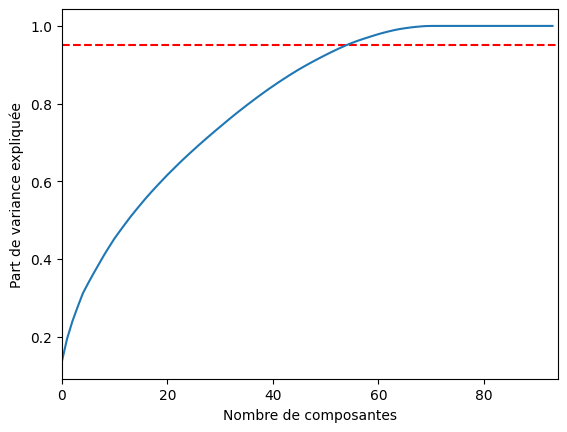

In [7]:
# Nombre de composantes pour 95% dela variance expliquée cumulée:
plt.figure()
plt.xlim(0,94)
plt.xlabel('Nombre de composantes')
plt.ylabel('Part de variance expliquée')
plt.axhline(y = 0.95, color ='r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

In [8]:
# On en précisant directement en PCA:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)

In [9]:
X_train_pca.shape

(20569, 55)

In [10]:
pca.components_.shape

(55, 94)

In [11]:
pca.components_

array([[-0.16100865,  0.17365911,  0.14913344, ...,  0.20218722,
        -0.20218722,  0.20218722],
       [-0.0003179 , -0.17381533, -0.09641116, ...,  0.12616434,
        -0.12616434,  0.12616434],
       [ 0.0559645 ,  0.0084079 , -0.00364227, ...,  0.19727949,
        -0.19727949,  0.19727949],
       ...,
       [ 0.11080802,  0.01057713, -0.17317141, ..., -0.05240455,
         0.05240455, -0.05240455],
       [ 0.07412126, -0.08095244,  0.03774352, ...,  0.03529125,
        -0.03529125,  0.03529125],
       [-0.27800727, -0.11742335, -0.0106019 , ..., -0.01172895,
         0.01172895, -0.01172895]], shape=(55, 94))

In [12]:
feature_contribution = pca.components_.T* np.sqrt(pca.explained_variance_)

In [13]:
feature_contribution.shape

(94, 55)

In [14]:
df_feature_contribution = pd.DataFrame(data=feature_contribution, index = X_train.columns)

In [15]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,-5.525755e-01,-7.225618e-04,1.102349e-01,-3.074088e-02,1.519663e-02,-3.669850e-02,-1.510382e-01,-5.116196e-02,6.008046e-02,1.181497e-01,...,-8.948384e-02,1.704994e-02,0.023952,-3.303960e-01,1.742845e-01,-3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,-2.002125e-01
surface,5.959914e-01,-3.950702e-01,1.656130e-02,3.175748e-01,-1.647088e-01,8.681998e-02,-1.651111e-01,3.450946e-02,8.828144e-03,-2.505691e-02,...,-1.384947e-02,1.112195e-03,-0.037671,7.787265e-02,-3.343941e-02,2.757653e-02,-3.405661e-02,7.964299e-03,-5.989567e-02,-8.456477e-02
surface_terrain,5.118202e-01,-2.191359e-01,-7.174292e-03,1.218496e-01,-1.413086e-02,1.675723e-02,-2.122340e-01,3.497216e-02,-4.768682e-02,9.635400e-04,...,-9.173111e-02,-1.689268e-01,0.051860,-2.032196e-01,2.580185e-01,7.150896e-02,-2.678716e-01,-1.303935e-01,2.792594e-02,-7.635167e-03
nb_pieces,6.247306e-01,-4.019202e-01,-1.579520e-02,3.472805e-01,-1.668895e-01,6.188408e-02,-1.796133e-01,4.591156e-02,1.774676e-02,-2.465481e-02,...,-6.908270e-02,2.359420e-02,-0.030944,6.387182e-02,-3.269559e-02,5.202419e-02,-1.554462e-03,1.772170e-02,-6.555970e-02,-8.214550e-02
mensualiteFinance,-1.488376e-18,2.365744e-17,-3.280258e-16,-1.876734e-16,-3.038872e-17,-6.258036e-17,-8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,-1.759321e-16,1.198383e-16,-0.000000,6.628556e-17,-5.487975e-17,-3.239618e-16,-3.082709e-16,2.680977e-16,-1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,-5.607959e-02,1.907659e-02,2.696464e-02,-2.936398e-02,3.171731e-02,-3.373826e-02,-3.003168e-04,-2.283787e-02,...,-7.737838e-03,4.806063e-02,0.038106,3.363649e-02,-1.670085e-03,8.147438e-03,-9.447604e-03,8.846809e-03,-4.927393e-03,-2.823790e-03
TYP_IRIS_x_H,-6.944878e-01,-2.878461e-01,-3.855598e-01,3.289805e-01,-2.089866e-01,-1.499926e-01,1.658691e-01,5.447879e-02,-1.337150e-01,1.087427e-01,...,-1.889237e-03,-6.382297e-02,-0.041125,9.450348e-03,-1.448902e-02,-2.611792e-02,1.011952e-03,3.898164e-02,-2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,-3.300102e-01,2.075306e-01,1.515778e-01,-1.675813e-01,-5.265723e-02,1.337311e-01,-1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,-1.126636e-02,1.457917e-02,2.567802e-02,-5.018778e-04,-3.945924e-02,2.611154e-02,-8.446840e-03
TYP_IRIS_y_H,-6.938988e-01,-2.867628e-01,-3.885872e-01,3.300102e-01,-2.075306e-01,-1.515778e-01,1.675813e-01,5.265723e-02,-1.337311e-01,1.075096e-01,...,-2.306999e-03,-6.122814e-02,-0.039068,1.126636e-02,-1.457917e-02,-2.567802e-02,5.018778e-04,3.945924e-02,-2.611154e-02,8.446840e-03


In [16]:
df_feature_contribution = df_feature_contribution.abs()

In [17]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,5.525755e-01,7.225618e-04,1.102349e-01,3.074088e-02,1.519663e-02,3.669850e-02,1.510382e-01,5.116196e-02,6.008046e-02,1.181497e-01,...,8.948384e-02,1.704994e-02,0.023952,3.303960e-01,1.742845e-01,3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,2.002125e-01
surface,5.959914e-01,3.950702e-01,1.656130e-02,3.175748e-01,1.647088e-01,8.681998e-02,1.651111e-01,3.450946e-02,8.828144e-03,2.505691e-02,...,1.384947e-02,1.112195e-03,0.037671,7.787265e-02,3.343941e-02,2.757653e-02,3.405661e-02,7.964299e-03,5.989567e-02,8.456477e-02
surface_terrain,5.118202e-01,2.191359e-01,7.174292e-03,1.218496e-01,1.413086e-02,1.675723e-02,2.122340e-01,3.497216e-02,4.768682e-02,9.635400e-04,...,9.173111e-02,1.689268e-01,0.051860,2.032196e-01,2.580185e-01,7.150896e-02,2.678716e-01,1.303935e-01,2.792594e-02,7.635167e-03
nb_pieces,6.247306e-01,4.019202e-01,1.579520e-02,3.472805e-01,1.668895e-01,6.188408e-02,1.796133e-01,4.591156e-02,1.774676e-02,2.465481e-02,...,6.908270e-02,2.359420e-02,0.030944,6.387182e-02,3.269559e-02,5.202419e-02,1.554462e-03,1.772170e-02,6.555970e-02,8.214550e-02
mensualiteFinance,1.488376e-18,2.365744e-17,3.280258e-16,1.876734e-16,3.038872e-17,6.258036e-17,8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,1.759321e-16,1.198383e-16,0.000000,6.628556e-17,5.487975e-17,3.239618e-16,3.082709e-16,2.680977e-16,1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,5.607959e-02,1.907659e-02,2.696464e-02,2.936398e-02,3.171731e-02,3.373826e-02,3.003168e-04,2.283787e-02,...,7.737838e-03,4.806063e-02,0.038106,3.363649e-02,1.670085e-03,8.147438e-03,9.447604e-03,8.846809e-03,4.927393e-03,2.823790e-03
TYP_IRIS_x_H,6.944878e-01,2.878461e-01,3.855598e-01,3.289805e-01,2.089866e-01,1.499926e-01,1.658691e-01,5.447879e-02,1.337150e-01,1.087427e-01,...,1.889237e-03,6.382297e-02,0.041125,9.450348e-03,1.448902e-02,2.611792e-02,1.011952e-03,3.898164e-02,2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03
TYP_IRIS_y_H,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03


In [18]:
df_feature_contribution['mean_contribution'] = df_feature_contribution.mean(axis=1)

In [19]:
df_feature_contribution['mean_contribution'].sort_values(ascending=False)

dpe_B                     1.087458e-01
Latitude_scaled           1.084276e-01
ges_G                     1.075901e-01
ges_A                     1.057258e-01
dpe_G                     1.048555e-01
                              ...     
REG                       7.692062e-17
energie_inconnue          4.775794e-17
chauf_inconnu             4.045755e-17
chauffage_mode_inconnu    2.087458e-17
type_annonceur_pr         1.068918e-17
Name: mean_contribution, Length: 94, dtype: float64

In [20]:
# Pour différentes valeurs d'un seuil de contribution, on regarde combien de features on garderait

for threshold in [0.1, 0.08, 0.06, 0.04, 0.02, 0.01]:
    feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > threshold]
    index_selected = feature_selected.index
    print(f"seuil: {threshold}, nombre de features selectionnées: {len(index_selected)}")

seuil: 0.1, nombre de features selectionnées: 13
seuil: 0.08, nombre de features selectionnées: 48
seuil: 0.06, nombre de features selectionnées: 78
seuil: 0.04, nombre de features selectionnées: 87
seuil: 0.02, nombre de features selectionnées: 87
seuil: 0.01, nombre de features selectionnées: 87


In [21]:
feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > 0.06]
features_selected_pca = list(feature_selected.index)
features_selected_pca

['etage',
 'surface',
 'surface_terrain',
 'nb_pieces',
 'balcon',
 'eau',
 'bain',
 'dpeC',
 'nb_etages',
 'places_parking',
 'cave',
 'annee_construction',
 'nb_toilettes',
 'nb_logements_copro',
 'charges_copro',
 'logement_neuf',
 'IRIS',
 'prix_m2_vente',
 'Latitude_scaled',
 'Longitude_scaled',
 'prix_bien_target_encoding',
 'annee_2019',
 'annee_2020',
 'annee_2021',
 'annee_2022',
 'annee_2023',
 'expo_nord',
 'expo_sud',
 'expo_est',
 'expo_ouest',
 'expo_inconnue',
 'chauf_radiateur',
 'chauf_sol',
 'chauf_convecteur',
 'chauf_poele_bois',
 'chauf_pac',
 'chauf_clim_rev',
 'chauf_cheminee',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'energie_bois',
 'dpe_A',
 'dpe_B',
 'dpe_C',
 'dpe_D',
 'dpe_E',
 'dpe_F',
 'dpe_G',
 'dpe_inconnu',
 'ges_A',
 'ges_B',
 'ges_C',
 'ges_D',
 'ges_E',
 'ges_F',
 'ges_G',
 'ges_inconnu',
 'chauffage_mode_individuel',
 'chauffage_mode_collectif',
 'chauffage_mode_central',
 'typedetransaction_pi',
 'typedetransaction_v',
 'typedetransacti

## 14.3) Matthieu

### 14.3.1) LinearRegression

LinearRegression sur l'ensemble des Features

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Scores
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985


Coefficients des Features

In [23]:
# Création du dictionnaire avec les coefficients absolus
columns_coef = dict(zip(X_train.columns, np.abs(lr.coef_[0]).tolist()))

# Tri par ordre décroissant des coefficients
columns_coef_trie = dict(sorted(columns_coef.items(), key=lambda item: item[1], reverse=True))

# Création du DataFrame avec l'ordre, la feature et le coefficient
df_resultats = pd.DataFrame([
    {'Ordre d\'importance': i, 'Feature': feature, 'Coefficient en valeur absolue': coef}
    for i, (feature, coef) in enumerate(columns_coef_trie.items(), start=1)
])

df_resultats.head(10)


,Ordre d'importance,Feature,Coefficient en valeur absolue
0,1,surface,101690.270683
1,2,prix_m2_vente,96291.434537
2,3,prix_bien_target_encoding,40609.028414
3,4,nb_pieces,17839.449118
4,5,surface_terrain,7787.940575
5,6,ascenseur,7657.392469
6,7,Longitude_scaled,5930.848221
7,8,IRIS,5346.676171
8,9,UU2010,5313.970229
9,10,categorie_annonceur_cm,5253.494794


In [24]:
features_selected_lr = df_resultats['Feature'].tolist()
features_selected_lr

['surface',
 'prix_m2_vente',
 'prix_bien_target_encoding',
 'nb_pieces',
 'surface_terrain',
 'ascenseur',
 'Longitude_scaled',
 'IRIS',
 'UU2010',
 'categorie_annonceur_cm',
 'logement_neuf',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'bain',
 'dpe_A',
 'chauf_sol',
 'chauffage_mode_collectif',
 'expo_sud',
 'charges_copro',
 'dpeC',
 'annee_construction',
 'typedebien_lite_m',
 'typedebien_a',
 'typedebien_m',
 'typedebien_lite_a',
 'chauffage_mode_individuel',
 'dpe_inconnu',
 'expo_inconnue',
 'ges_inconnu',
 'categorie_annonceur_ca',
 'eau',
 'categorie_annonceur_a',
 'categorie_annonceur_b',
 'nb_toilettes',
 'dpe_C',
 'etage',
 'ges_A',
 'categorie_annonceur_network',
 'chauf_pac',
 'annonce_exclusive_Non',
 'dpe_F',
 'energie_bois',
 'ges_E',
 'typedetransaction_v',
 'cave',
 'typedetransaction_vp',
 'dpe_D',
 'categorie_annonceur_m',
 'annonce_exclusive_Oui',
 'Latitude_scaled',
 'nb_logements_copro',
 'ges_C',
 'dpe_G',
 'dpe_E',
 'nb_etages',
 'annee_2019',
 'ges_B

<Axes: >

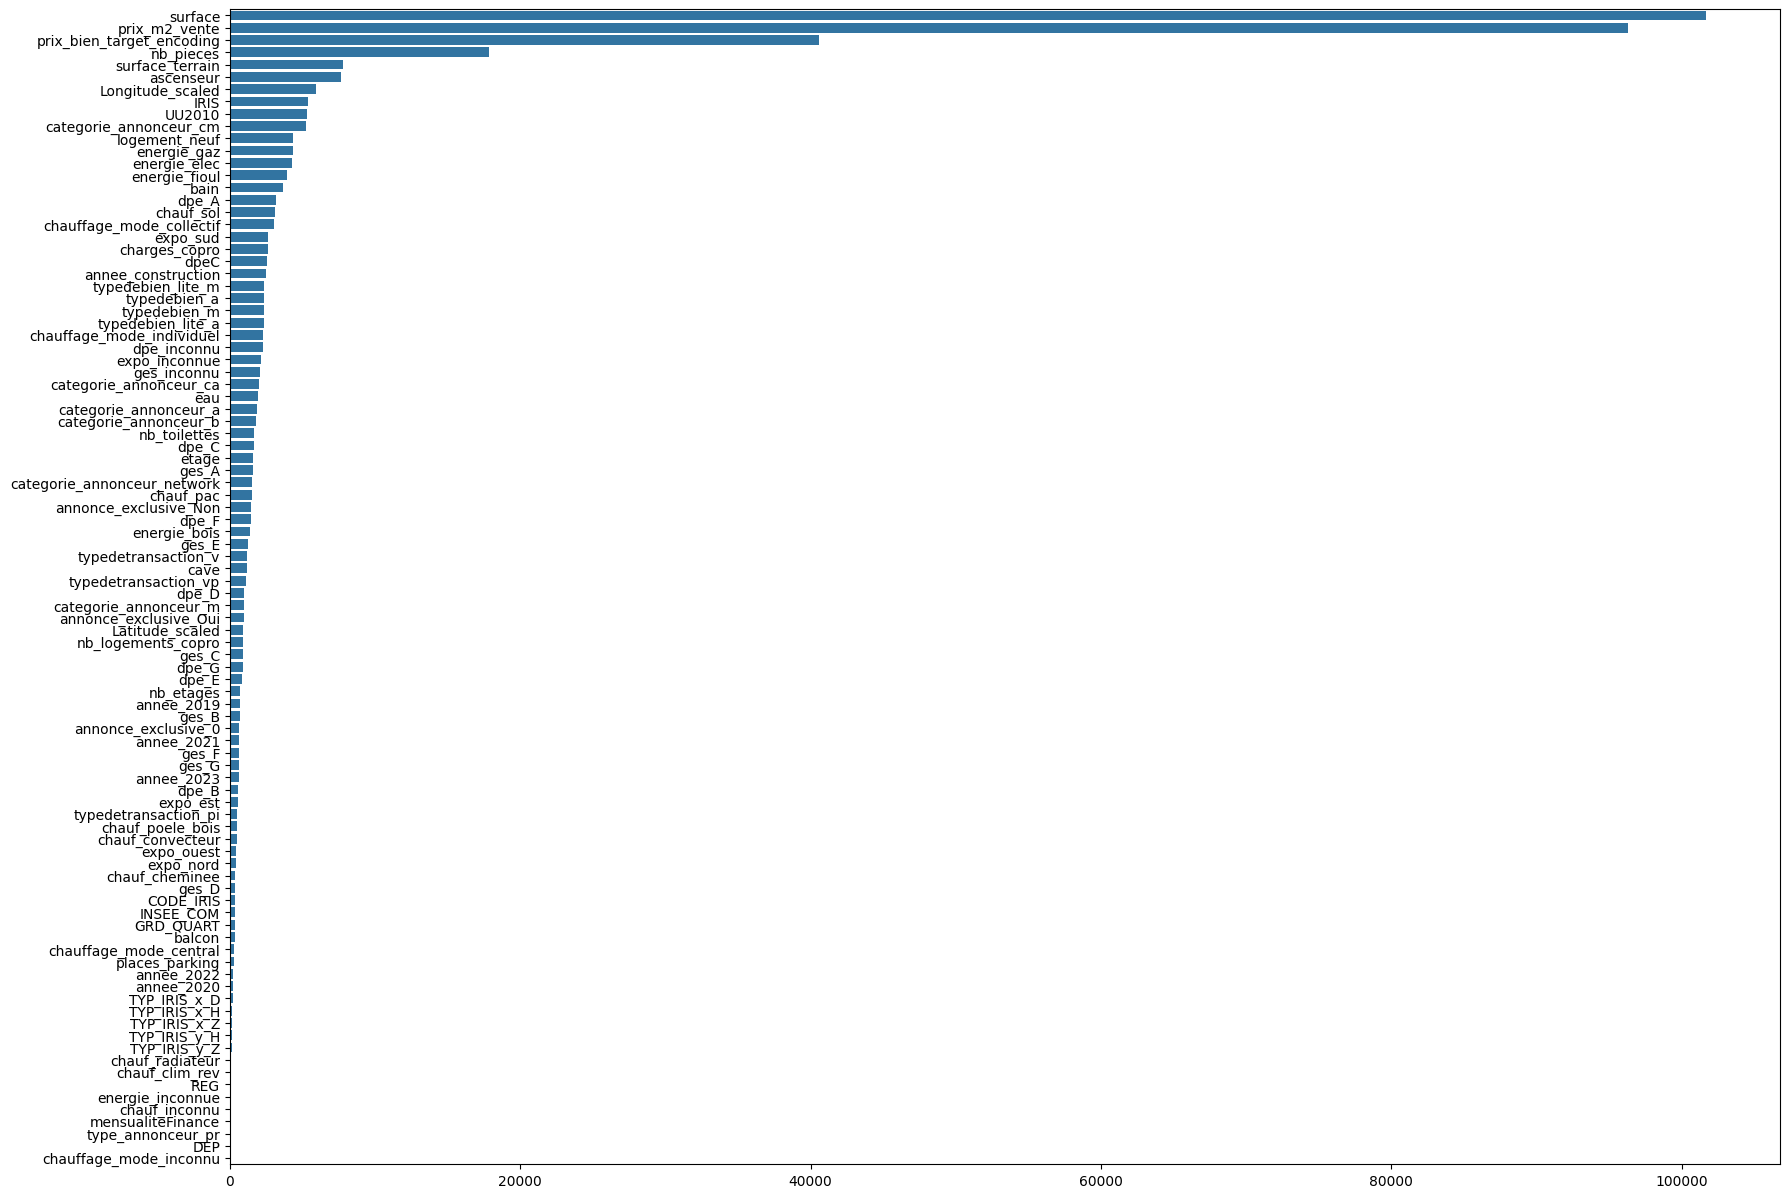

In [25]:
fig, ax = plt.subplots(figsize = (20,15))
sns.barplot(x=columns_coef_trie.values(), y=columns_coef_trie.keys())

LinearRegression en ne gardant que les 10 plus gros coefficient

In [26]:
lr_10 = LinearRegression()
lr_10.fit(X_train[df_resultats.Feature[:10].values.tolist()], y_train)

y_pred_lr_10 = lr_10.predict(X_test[df_resultats.Feature[:10].values.tolist()])

# Scores
mae_lr_10 = mean_absolute_error(y_test, y_pred_lr_10)
rmse_lr_10 = np.sqrt(mean_squared_error(y_test, y_pred_lr_10))
r2_lr_10 = r2_score(y_test, y_pred_lr_10)

print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")


MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


Comparaison LinearRegression avec 94 Features et 10 Features

In [27]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


### 14.3.2) LinearRegression + Backward Elimination

SequentialFeatureSelector (backward)

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'eau', 'bain',
       'dpeC', 'cave', 'annee_construction', 'nb_toilettes', 'ascenseur',
       'charges_copro', 'logement_neuf', 'IRIS', 'GRD_QUART', 'UU2010',
       'prix_m2_vente', 'Latitude_scaled', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2023', 'expo_sud', 'expo_est',
       'expo_inconnue', 'chauf_sol', 'chauf_pac', 'energie_gaz', 'dpe_B',
       'dpe_C', 'dpe_D', 'dpe_E', 'dpe_F', 'dpe_G', 'dpe_inconnu', 'ges_B',
       'ges_C', 'ges_D', 'ges_G', 'ges_inconnu', 'chauffage_mode_collectif',
       'typedetransaction_pi', 'typedetransaction_vp', 'annonce_exclusive_Non',
       'categorie_annonceur_b', 'categorie_annonceur_cm',
       'categorie_annonceur_network', 'typedebien_lite_a'],
      dtype='object')
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983


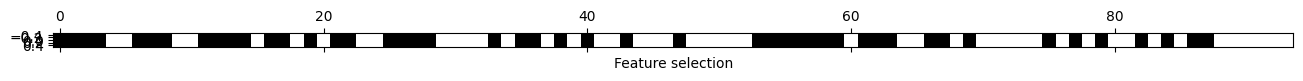

In [28]:
lr_backward_auto = LinearRegression()

# Backward Selection (recul)
sfs = SequentialFeatureSelector(
    lr_backward_auto,
    n_features_to_select='auto',
    direction="backward",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error"
)

sfs.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = sfs.get_support()
selected_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", selected_features)

# Modèle final sur features retenues
lr_backward_auto.fit(X_train[selected_features], y_train)
y_pred_lr_backward_auto = lr_backward_auto.predict(X_test[selected_features])

mae_lr_backward_auto = mean_absolute_error(y_test, y_pred_lr_backward_auto)
rmse_lr_backward_auto = np.sqrt(mean_squared_error(y_test, y_pred_lr_backward_auto))
r2_lr_backward_auto = r2_score(y_test, y_pred_lr_backward_auto)

print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")


In [29]:
features_selected_sfs = selected_features
len(features_selected_sfs)

47

In [30]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983


### 14.4.3) LinearRegression + SelectKBest

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'balcon', 'eau',
       'bain', 'dpeC', 'nb_etages', 'places_parking', 'nb_toilettes',
       'ascenseur', 'nb_logements_copro', 'charges_copro', 'logement_neuf',
       'IRIS', 'UU2010', 'prix_m2_vente', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2020', 'annee_2022', 'annee_2023',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'dpe_A', 'dpe_B',
       'dpe_E', 'ges_A', 'chauffage_mode_individuel',
       'chauffage_mode_collectif', 'typedebien_a', 'typedebien_m',
       'typedetransaction_v', 'typedetransaction_vp', 'annonce_exclusive_0',
       'annonce_exclusive_Oui', 'categorie_annonceur_a',
       'categorie_annonceur_cm', 'typedebien_lite_a', 'typedebien_lite_m',
       'TYP_IRIS_x_H', 'TYP_IRIS_x_Z', 'TYP_IRIS_y_H', 'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959


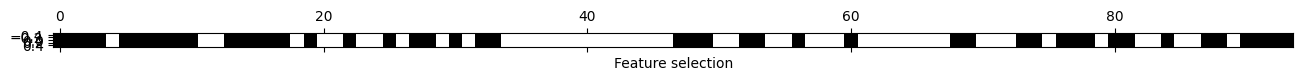

In [31]:
# Choix de K
k = 46

# SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = selector.get_support()
kbest_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", kbest_features)

# Modèle final
lr_kbest = LinearRegression()
lr_kbest.fit(X_train[kbest_features], y_train)

y_pred_kbest = lr_kbest.predict(X_test[kbest_features])

mae_kbest = mean_absolute_error(y_test, y_pred_kbest)
rmse_kbest = np.sqrt(mean_squared_error(y_test, y_pred_kbest))
r2_kbest = r2_score(y_test, y_pred_kbest)

print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")


In [32]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959


In [33]:
features_selected_kbest = kbest_features
len(features_selected_kbest)

46

In [34]:
selected_dict = { 'pca': features_selected_pca,
                  'lr': features_selected_lr,
                  'sfs': features_selected_sfs,
                  'kbest': features_selected_kbest}

In [35]:
joblib.dump(selected_dict, "selected_dict.joblib")

['selected_dict.joblib']

## 14.4) Intersection

In [36]:
#si l'on regarde l'intersection entre les features sélectionnées par la PCA et les features sélectionnées par la lr:
selected = set(selected_dict['pca'][:46]).intersection(set(selected_dict['lr'][:46])).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['prix_m2_vente',
 'eau',
 'IRIS',
 'prix_bien_target_encoding',
 'Longitude_scaled',
 'nb_toilettes',
 'nb_pieces',
 'surface_terrain',
 'dpeC',
 'logement_neuf',
 'bain',
 'charges_copro',
 'energie_gaz',
 'surface',
 'etage']

In [37]:
len(selected)

15

In [38]:
# Si on essaie une régression avec ces 15 features:
lr_15 = LinearRegression()
lr_15.fit(X_train[selected], y_train)

# Prédictions
y_pred_15 = lr_15.predict(X_test[selected])

# Scores
mae_15 = mean_absolute_error(y_test, y_pred_15)
rmse_15 = np.sqrt(mean_squared_error(y_test, y_pred_15))
r2_15 = r2_score(y_test, y_pred_15)

print(f"MAE  : {mae_15:.2f}")
print(f"RMSE : {rmse_15:.2f}")
print(f"R2   : {r2_15:.4f}")


MAE  : 33038.27
RMSE : 53103.04
R2   : 0.8887


In [39]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### Linear Regresion avec 15 Features (intersection des méthodes précédentes) ###")
print(f"MAE  : {mae_15:.2f}")
print(f"RMSE : {rmse_15:.2f}")
print(f"R2   : {r2_15:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### Linear Regresion avec 15 Features (intersection des méthodes précédentes) ###
MAE  : 33038.27
RMSE : 53103.04
R2   : 0.8887


On est un peu moins bien que pour uniquement les 15 features mais on est sur un seul type de modèle (régression linéaire). On verra par la suite avec les autres modèles et en optimisant ce que l'on obtiendra...

In [40]:
y_pred = pd.DataFrame(data = y_pred_15, index=y_test.index)

In [41]:
y_pred = y_pred.rename(columns={0: "prix_bien"})

In [42]:
diff = y_test - y_pred

In [43]:
y_test

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,115400
ag680297-277810664,106500
orpi-1-054041E1OWKF,118250
guy-hoquet-immo-facile-6243822,76000
ag440414-293552741,390000
...,...
immo-facile-35871425,100000
ag680254-273036872,210000
ag681158-373018354,72000


In [44]:
y_pred

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,171031.329178
ag680297-277810664,79130.964170
orpi-1-054041E1OWKF,89105.674323
guy-hoquet-immo-facile-6243822,45245.743635
ag440414-293552741,354738.620538
...,...
immo-facile-35871425,84732.066144
ag680254-273036872,232467.433558
ag681158-373018354,41700.313097


In [45]:
y_test.loc['ag681120-337284537', 'prix_bien']

np.int64(2300000)

In [46]:
diff

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-55631.329178
ag680297-277810664,27369.035830
orpi-1-054041E1OWKF,29144.325677
guy-hoquet-immo-facile-6243822,30754.256365
ag440414-293552741,35261.379462
...,...
immo-facile-35871425,15267.933856
ag680254-273036872,-22467.433558
ag681158-373018354,30299.686903


In [47]:
diff.idxmax()

prix_bien    ag681120-337284537
dtype: object

In [48]:
diff.loc['ag681120-337284537']

prix_bien    1.020508e+06
Name: ag681120-337284537, dtype: float64

In [49]:
print(f"prediction: {int(y_pred.loc['ag681120-337284537', 'prix_bien'])}, prix réel: {y_test.loc['ag681120-337284537', 'prix_bien']}")

prediction: 1279491, prix réel: 2300000


In [50]:
df_ventes.loc['ag681120-337284537']

type_annonceur                    pr
typedebien                         m
typedetransaction                  v
etage                              0
surface                          354
surface_terrain               1300.0
nb_pieces                          8
prix_bien                    2300000
prix_maison                      NaN
prix_terrain                     NaN
mensualiteFinance                  0
balcon                             0
eau                                0
bain                               0
dpeL                               B
dpeC                            89.0
mapCoordonneesLatitude      47.49404
mapCoordonneesLongitude      7.48269
annonce_exclusive                Non
nb_etages                        NaN
parking                          NaN
places_parking                   NaN
cave                             NaN
exposition                         0
ges_class                          B
annee_construction               NaN
nb_toilettes                     NaN
n

In [51]:
diff.to_csv("diff.csv", index=True)

# 15) DecisionTreeRegressor

In [4]:
tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
tree_pred = pd.DataFrame(tree_pred, index=y_test.index, columns=['prix_bien'])

mae_tree = mean_absolute_error(y_test, tree_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_pred))
r2_tree = r2_score(y_test, tree_pred)

print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

MAE  : 8331.69
RMSE : 32568.79
R2   : 0.9581


In [61]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### DecisionTreeRegressor avec 94 Features ###")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### DecisionTreeRegressor avec 94 Features ###
MAE  : 8478.03
RMSE : 34801.07
R2   : 0.9522


## 15.1) Feature importance

In [5]:
importance = tree.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)


,Feature,Importance
28,prix_bien_target_encoding,0.535726
25,prix_m2_vente,0.247145
1,surface,0.211369
8,dpeC,0.001298
5,balcon,0.000982
...,...,...
45,chauf_cheminee,0.000000
75,typedetransaction_pi,0.000000
72,type_annonceur_pr,0.000000
71,chauffage_mode_inconnu,0.000000


In [6]:
tree_feature_importances = DecisionTreeRegressor()

tree_feature_importances.fit(X_train[['prix_bien_target_encoding', 'prix_m2_vente', 'surface']], y_train)

tree_feature_importances_pred = tree_feature_importances.predict(X_test[['prix_bien_target_encoding', 'prix_m2_vente', 'surface']])
tree_feature_importances_pred = pd.DataFrame(tree_feature_importances_pred, index=y_test.index, columns=['prix_bien'])

mae_feature_importances = mean_absolute_error(y_test, tree_feature_importances_pred)
rmse_feature_importances = np.sqrt(mean_squared_error(y_test, tree_feature_importances_pred))
r2_feature_importances = r2_score(y_test, tree_feature_importances_pred)

print(f"MAE  : {mae_feature_importances:.2f}")
print(f"RMSE : {rmse_feature_importances:.2f}")
print(f"R2   : {r2_feature_importances:.4f}")

MAE  : 5916.61
RMSE : 24958.93
R2   : 0.9754


In [64]:
print("### Linear Regresion avec 94 Features ###")
print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

print("\n### Linear Regresion avec 10 Features ###")
print(f"MAE  : {mae_lr_10:.2f}")
print(f"RMSE : {rmse_lr_10:.2f}")
print(f"R2   : {r2_lr_10:.4f}")

print("\n### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###")
print(f"MAE  : {mae_lr_backward_auto:.2f}")
print(f"RMSE : {rmse_lr_backward_auto:.2f}")
print(f"R2   : {r2_lr_backward_auto:.4f}")

print("\n### Linear Regresion avec SelectKBest (k=46 Features) ###")
print(f"MAE  : {mae_kbest:.2f}")
print(f"RMSE : {rmse_kbest:.2f}")
print(f"R2   : {r2_kbest:.4f}")

print("\n### DecisionTreeRegressor avec 94 Features ###")
print(f"MAE  : {mae_tree:.2f}")
print(f"RMSE : {rmse_tree:.2f}")
print(f"R2   : {r2_tree:.4f}")

print("\n### DecisionTreeRegressor avec les 3 Features ayant une importance significative ###")
print(f"MAE  : {mae_feature_importances:.2f}")
print(f"RMSE : {rmse_feature_importances:.2f}")
print(f"R2   : {r2_feature_importances:.4f}")

### Linear Regresion avec 94 Features ###
MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985

### Linear Regresion avec 10 Features ###
MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903

### Linear Regresion avec Backward Elimination n_features_to_select='auto' (47 Features) ###
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983

### Linear Regresion avec SelectKBest (k=46 Features) ###
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959

### DecisionTreeRegressor avec 94 Features ###
MAE  : 8478.03
RMSE : 34801.07
R2   : 0.9522

### DecisionTreeRegressor avec les 3 Features ayant une importance significative ###
MAE  : 5820.25
RMSE : 22690.36
R2   : 0.9797


In [7]:
importance = tree_feature_importances.feature_importances_
feature_names = ['prix_bien_target_encoding', 'prix_m2_vente', 'surface']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
display(importance_df)


,Feature,Importance
0,prix_bien_target_encoding,0.536286
1,prix_m2_vente,0.249206
2,surface,0.214508


In [66]:
# Création d'un dictionnaire avec les données
data = {
    "Modèle": [
        "Linear Regression (94 features)",
        "Linear Regression (10 features)",
        "Linear Regression (backward elimination, auto)",
        "Linear Regression (SelectKBest, k=46)",
        "DecisionTreeRegressor (94 features)",
        "DecisionTreeRegressor (3 features)"
    ],
    "MAE": [
        mae_lr,
        mae_lr_10,
        mae_lr_backward_auto,
        mae_kbest,
        mae_tree,
        mae_feature_importances
    ],
    "RMSE": [
        rmse_lr,
        rmse_lr_10,
        rmse_lr_backward_auto,
        rmse_kbest,
        rmse_tree,
        rmse_feature_importances
    ],
    "R2": [
        r2_lr,
        r2_lr_10,
        r2_lr_backward_auto,
        r2_kbest,
        r2_tree,
        r2_feature_importances
    ]
}

# Conversion en DataFrame
results_df = pd.DataFrame(data)

# Affichage du DataFrame
print(results_df)

                                           Modèle           MAE          RMSE  \
0                 Linear Regression (94 features)  31428.468446  50699.135680   
1                 Linear Regression (10 features)  32778.685426  52717.446296   
2  Linear Regression (backward elimination, auto)  31497.496354  50755.380841   
3           Linear Regression (SelectKBest, k=46)  31901.385458  51343.128335   
4             DecisionTreeRegressor (94 features)   8478.030232  34801.071798   
5              DecisionTreeRegressor (3 features)   5820.252974  22690.359576   

         R2  
0  0.898518  
1  0.890277  
2  0.898292  
3  0.895923  
4  0.952184  
5  0.979673  


# 16) Focus sur les 'mauvaises' prédictions avec DecisionTreeRegressor

In [8]:
tree_diff = y_test - tree_feature_importances_pred

In [9]:
df_tree_diff = pd.merge(tree_diff.sort_values(by='prix_bien', ascending=False), df_ventes, how='left', left_index=True, right_index=True).rename(columns={"prix_bien_x": "delta_prediction"})

## 16.1) Variables catégorielles

In [10]:
df_tree_diff_mauvaises_pred = df_tree_diff[np.abs(df_tree_diff['delta_prediction']) > 10000]
df_tree_diff_mauvaises_pred.shape

(545, 59)



#### Variable  type_annonceur  ####
|delta_prediction| < 10000
type_annonceur
pr    4582
Name: count, dtype: int64

delta_prediction > 10000
type_annonceur
pr    296
Name: count, dtype: int64

delta_prediction < -10000
type_annonceur
pr    249
Name: count, dtype: int64


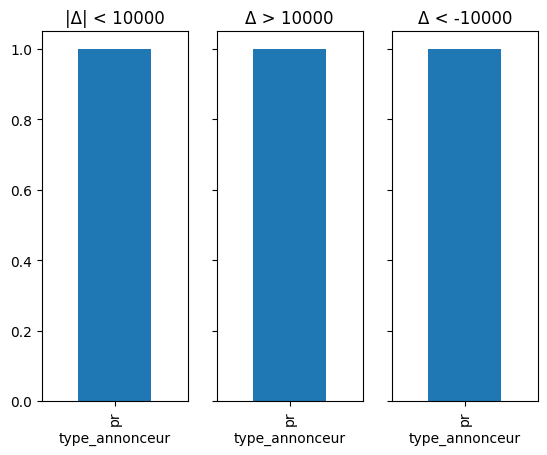



#### Variable  typedebien  ####
|delta_prediction| < 10000
typedebien
a     2278
m     2078
mn     120
an     106
Name: count, dtype: int64

delta_prediction > 10000
typedebien
m     235
a      57
mn      3
an      1
Name: count, dtype: int64

delta_prediction < -10000
typedebien
m     184
a      58
mn      5
an      2
Name: count, dtype: int64


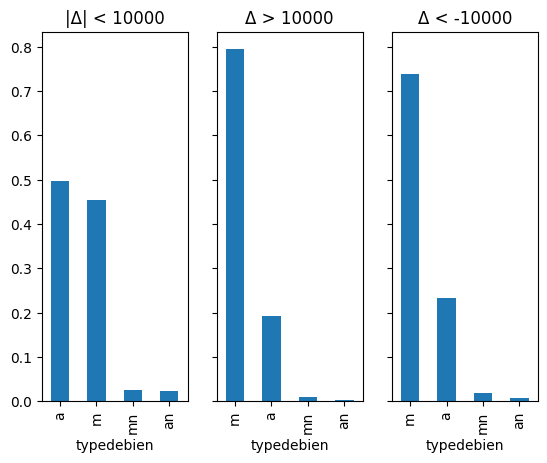



#### Variable  typedetransaction  ####
|delta_prediction| < 10000
typedetransaction
v     4549
vp      33
Name: count, dtype: int64

delta_prediction > 10000
typedetransaction
v     285
vp     11
Name: count, dtype: int64

delta_prediction < -10000
typedetransaction
v     241
vp      8
Name: count, dtype: int64


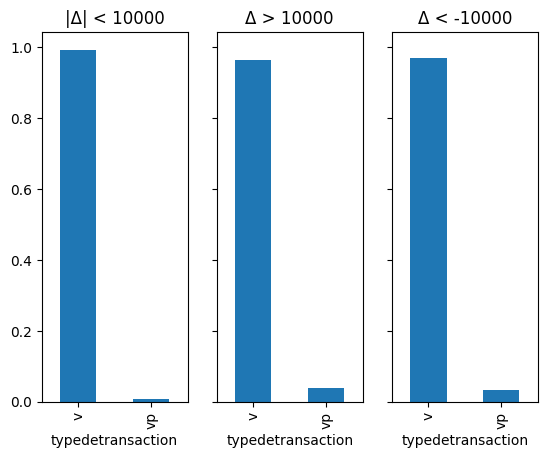



#### Variable  dpeL  ####
|delta_prediction| < 10000
dpeL
D     967
0     818
E     669
C     666
NS    390
B     280
VI    278
F     257
A     176
G      81
Name: count, dtype: int64

delta_prediction > 10000
dpeL
D     78
E     47
C     46
0     32
B     25
A     20
VI    18
F     15
NS     9
G      6
Name: count, dtype: int64

delta_prediction < -10000
dpeL
D     50
0     37
C     36
E     29
F     22
A     22
NS    17
VI    14
B     13
G      9
Name: count, dtype: int64


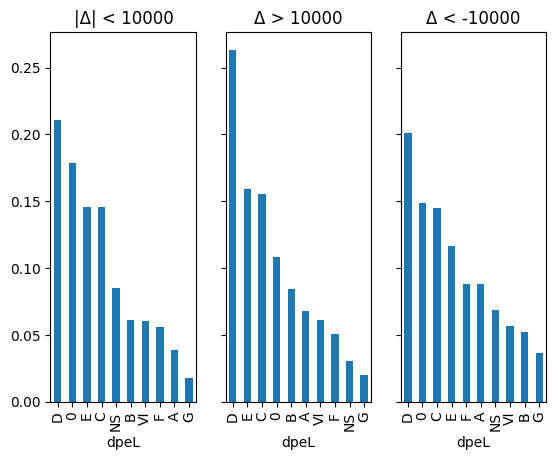



#### Variable  annonce_exclusive  ####
|delta_prediction| < 10000
annonce_exclusive
Oui    1995
Non    1852
0       735
Name: count, dtype: int64

delta_prediction > 10000
annonce_exclusive
Oui    142
Non    114
0       40
Name: count, dtype: int64

delta_prediction < -10000
annonce_exclusive
Oui    121
Non     88
0       40
Name: count, dtype: int64


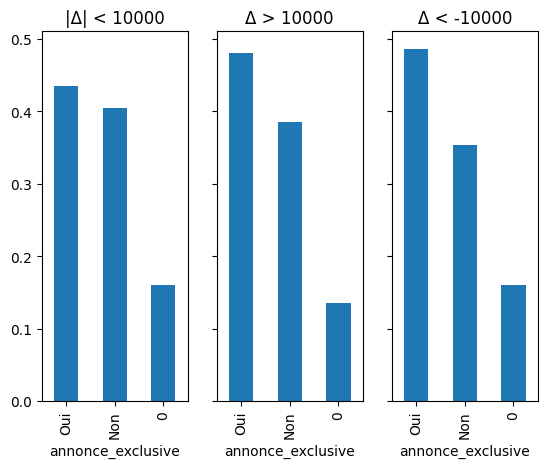



#### Variable  parking  ####
|delta_prediction| < 10000
parking
True     5
False    1
Name: count, dtype: int64

delta_prediction > 10000
Series([], Name: count, dtype: int64)

delta_prediction < -10000
Series([], Name: count, dtype: int64)


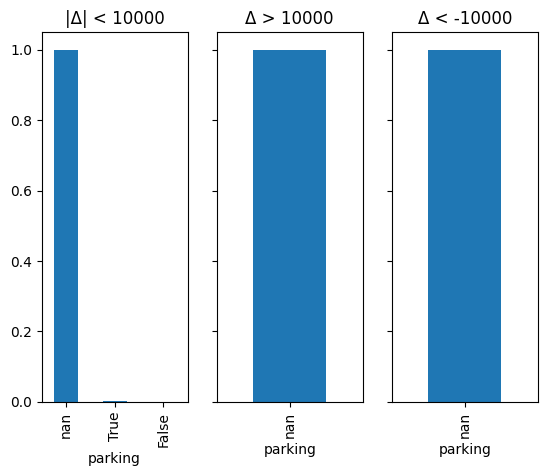



#### Variable  cave  ####
|delta_prediction| < 10000
cave
True     1464
False     783
Name: count, dtype: int64

delta_prediction > 10000
cave
True     85
False    50
Name: count, dtype: int64

delta_prediction < -10000
cave
True     73
False    46
Name: count, dtype: int64


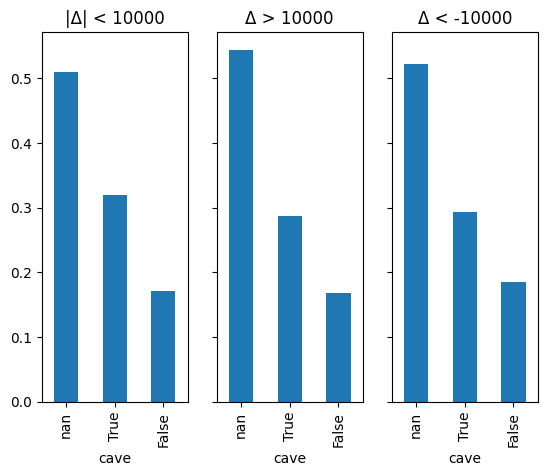



#### Variable  exposition  ####
|delta_prediction| < 10000
exposition
0                       3529
Sud                      368
Est                      113
Sud-Ouest                 94
Ouest                     92
Nord-Ouest                81
Sud-Est                   74
Est-Ouest                 59
sud-ouest                 35
Sud-Est-Ouest             33
Nord-Sud                  29
Nord                      24
sud-est                   15
Nord-Est                   9
traversant                 5
nord,est                   3
Nord Est Ouest             3
Nord Sud Est Ouest         3
Nord Sud Ouest             3
nord-est / sud-ouest       2
Nord Sud Est               2
Nord-ouest                 1
sud,ouest                  1
sud ouest                  1
nord-ouest / sud-est       1
nord,ouest                 1
traversant nord-sud        1
Name: count, dtype: int64

delta_prediction > 10000
exposition
0                234
Sud               24
Sud-Ouest         10
Est-Ouest          

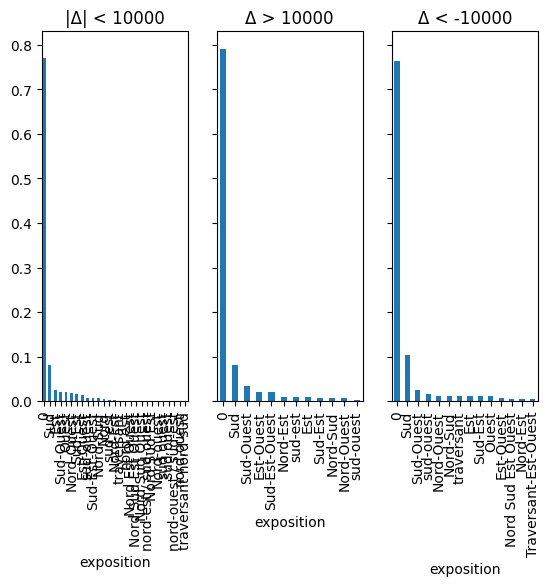



#### Variable  ges_class  ####
|delta_prediction| < 10000
ges_class
D     656
C     542
E     541
B     443
A     314
F     274
VI    241
G     166
NS    111
Name: count, dtype: int64

delta_prediction > 10000
ges_class
E     45
D     42
C     41
B     31
A     29
F     21
VI    16
G     10
NS     4
Name: count, dtype: int64

delta_prediction < -10000
ges_class
D     42
E     29
A     26
C     26
B     19
F     16
VI    11
NS    10
G      9
Name: count, dtype: int64


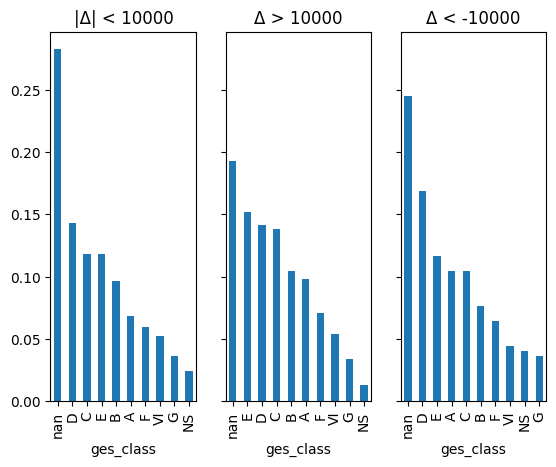



#### Variable  videophone  ####
|delta_prediction| < 10000
videophone
True     13
False     7
Name: count, dtype: int64

delta_prediction > 10000
Series([], Name: count, dtype: int64)

delta_prediction < -10000
videophone
False    1
Name: count, dtype: int64


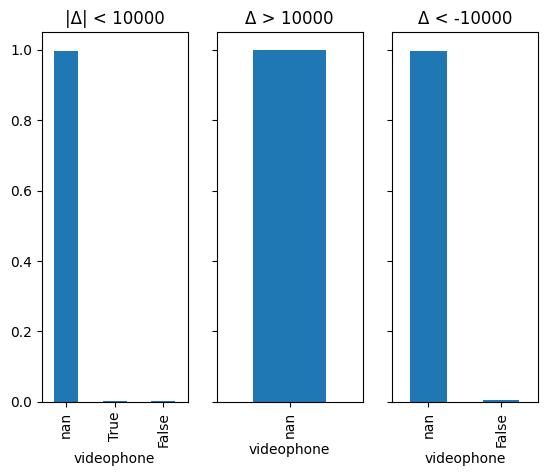



#### Variable  porte_digicode  ####
|delta_prediction| < 10000
porte_digicode
False    623
True      96
Name: count, dtype: int64

delta_prediction > 10000
porte_digicode
False    55
True      3
Name: count, dtype: int64

delta_prediction < -10000
porte_digicode
False    37
True      2
Name: count, dtype: int64


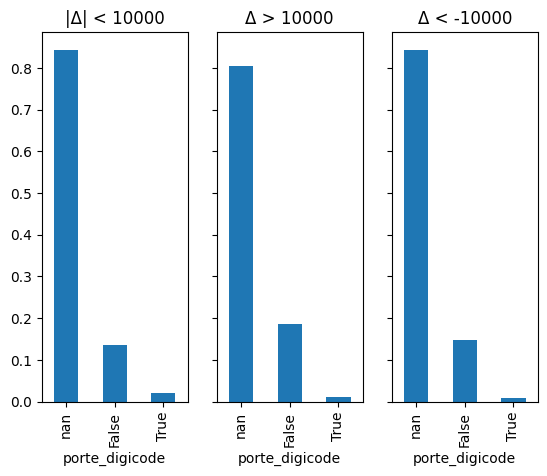



#### Variable  ascenseur  ####
|delta_prediction| < 10000
ascenseur
True     803
False    694
Name: count, dtype: int64

delta_prediction > 10000
ascenseur
True     21
False    14
Name: count, dtype: int64

delta_prediction < -10000
ascenseur
True     24
False    16
Name: count, dtype: int64


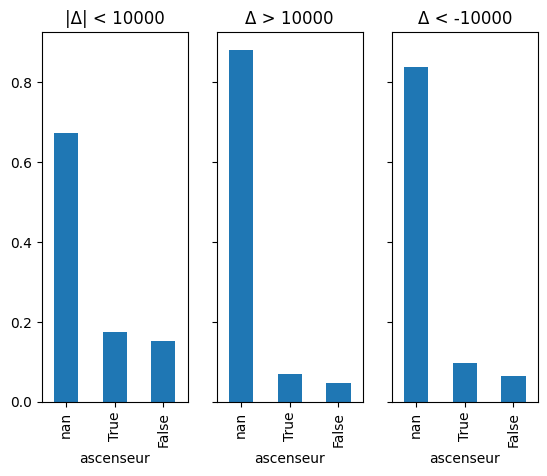



#### Variable  chauffage_energie  ####
|delta_prediction| < 10000
chauffage_energie
Gaz                 1356
Électrique           440
Fioul                320
Bois                  13
Électrique, Bois       3
Gaz, Bois              1
Name: count, dtype: int64

delta_prediction > 10000
chauffage_energie
Gaz           71
Fioul         36
Électrique    19
Bois           1
Gaz, Bois      1
Name: count, dtype: int64

delta_prediction < -10000
chauffage_energie
Gaz                49
Fioul              24
Électrique         22
Bois                2
Gaz, Électrique     1
Name: count, dtype: int64


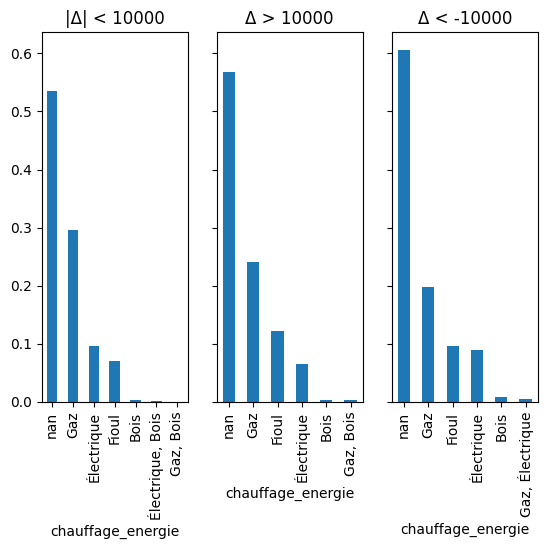



#### Variable  chauffage_systeme  ####
|delta_prediction| < 10000
chauffage_systeme
Radiateur                     1069
Sol                            174
Convecteur                      14
Pompe à chaleur, Sol             9
Poêle à Bois                     8
Pompe à chaleur                  4
Pompe à chaleur, Radiateur       3
Climatisation révérsible         3
Sol, Radiateur                   1
Sol, Cheminée                    1
Name: count, dtype: int64

delta_prediction > 10000
chauffage_systeme
Radiateur          69
Sol                12
Pompe à chaleur     2
Poêle à Bois        2
Name: count, dtype: int64

delta_prediction < -10000
chauffage_systeme
Radiateur               57
Sol                     13
Pompe à chaleur, Sol     1
Poêle à Bois             1
Convecteur               1
Pompe à chaleur          1
Name: count, dtype: int64


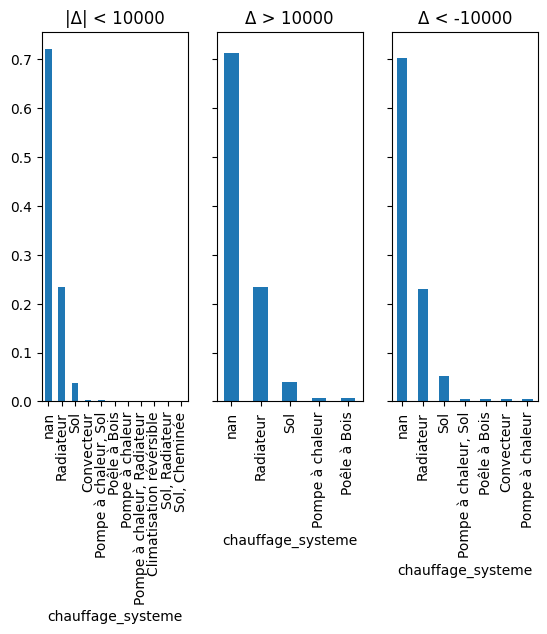



#### Variable  chauffage_mode  ####
|delta_prediction| < 10000
chauffage_mode
Individuel               1943
Collectif                 377
Collectif, Individuel      18
Individuel, Central         3
Collectif, Central          2
Central                     2
Name: count, dtype: int64

delta_prediction > 10000
chauffage_mode
Individuel               140
Collectif                  7
Collectif, Individuel      1
Name: count, dtype: int64

delta_prediction < -10000
chauffage_mode
Individuel    104
Collectif      18
Central         1
Name: count, dtype: int64


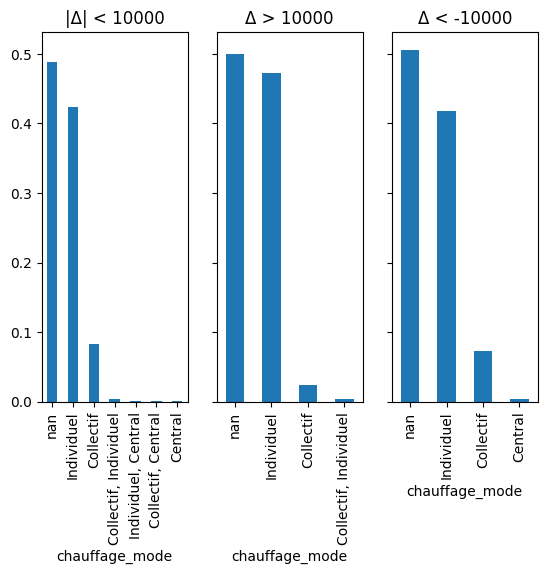



#### Variable  categorie_annonceur  ####
|delta_prediction| < 10000
categorie_annonceur
a          3445
cm          509
m           382
ca          184
network      57
b             5
Name: count, dtype: int64

delta_prediction > 10000
categorie_annonceur
a          222
m           35
cm          31
network      5
ca           3
Name: count, dtype: int64

delta_prediction < -10000
categorie_annonceur
a          190
cm          27
m           26
ca           4
network      1
b            1
Name: count, dtype: int64


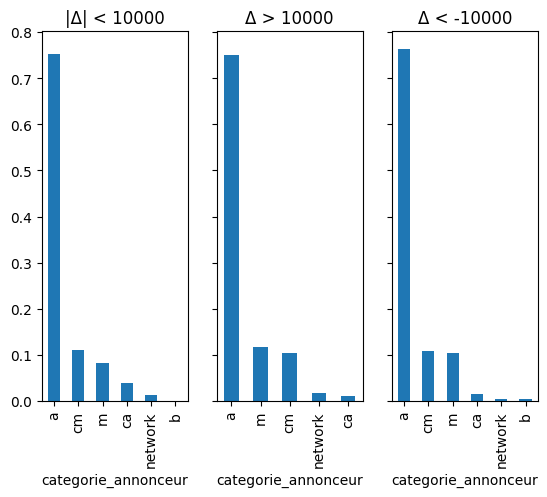



#### Variable  logement_neuf  ####
|delta_prediction| < 10000
logement_neuf
n    3841
o     624
Name: count, dtype: int64

delta_prediction > 10000
logement_neuf
n    264
o     29
Name: count, dtype: int64

delta_prediction < -10000
logement_neuf
n    217
o     26
Name: count, dtype: int64


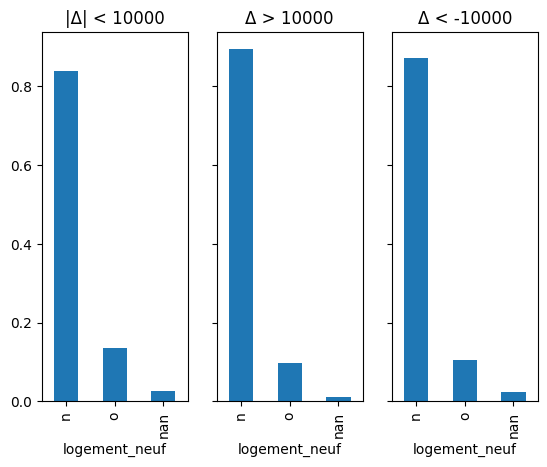



#### Variable  typedebien_lite  ####
|delta_prediction| < 10000
typedebien_lite
a    2384
m    2198
Name: count, dtype: int64

delta_prediction > 10000
typedebien_lite
m    238
a     58
Name: count, dtype: int64

delta_prediction < -10000
typedebien_lite
m    189
a     60
Name: count, dtype: int64


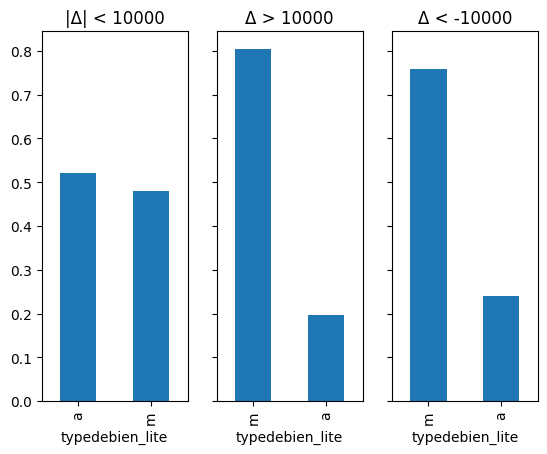



#### Variable  date  ####
|delta_prediction| < 10000
date
2020-01    218
2023-03    181
2020-07    180
2023-02    179
2021-10    177
2022-10    169
2022-09    161
2023-04    150
2022-02    149
2023-01    142
2022-05    142
2022-07    130
2022-11    130
2022-04    127
2022-12    123
2022-01    118
2022-06    117
2021-04    111
2022-03    108
2021-11    103
2021-06    101
2020-12    100
2021-09     99
2022-08     98
2021-02     93
2020-02     93
2020-09     88
2021-12     88
2021-08     87
2021-01     86
2020-06     83
2020-10     78
2021-03     76
2020-05     71
2021-05     69
2021-07     68
2020-03     65
2020-11     60
2020-08     42
2020-04     24
2019-09     23
2019-02     19
2019-11     13
2019-12     13
2019-05      8
2019-04      7
2019-08      5
2019-10      4
2019-06      4
2019-03      1
2019-07      1
Name: count, dtype: int64

delta_prediction > 10000
date
2020-01    17
2022-12    16
2023-04    14
2022-03    13
2022-11    13
2022-10    11
2022-09    11
2023-01    11
2021-1

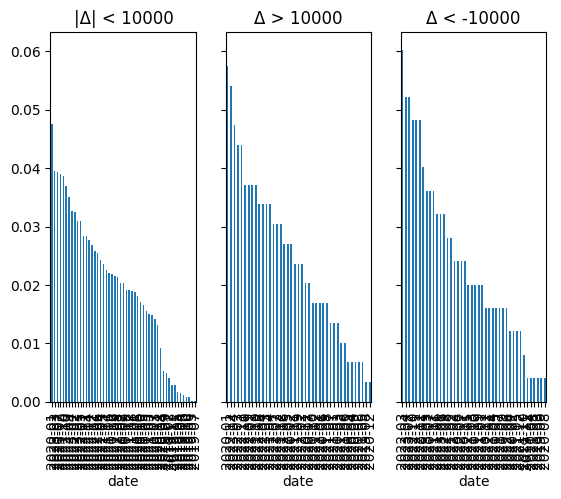



#### Variable  TYP_IRIS_x  ####
|delta_prediction| < 10000
TYP_IRIS_x
H    2291
Z    2289
D       2
Name: count, dtype: int64

delta_prediction > 10000
TYP_IRIS_x
Z    176
H    120
Name: count, dtype: int64

delta_prediction < -10000
TYP_IRIS_x
Z    143
H    106
Name: count, dtype: int64


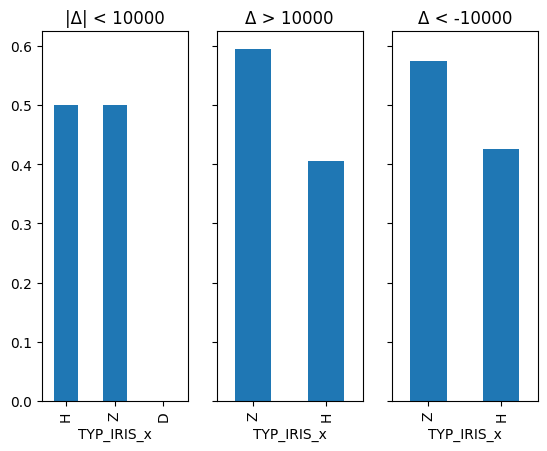



#### Variable  TYP_IRIS_y  ####
|delta_prediction| < 10000
TYP_IRIS_y
H    2293
Z    2289
Name: count, dtype: int64

delta_prediction > 10000
TYP_IRIS_y
Z    176
H    120
Name: count, dtype: int64

delta_prediction < -10000
TYP_IRIS_y
Z    143
H    106
Name: count, dtype: int64


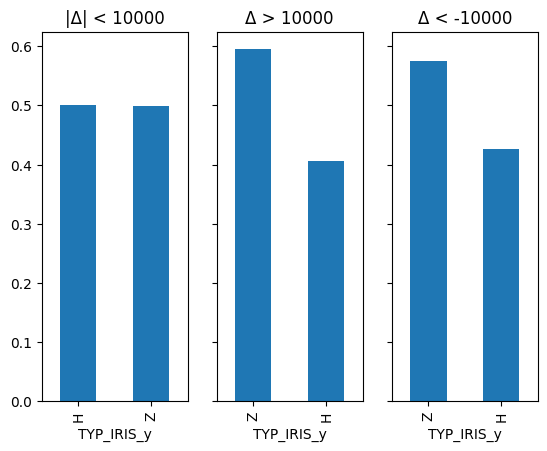

In [17]:
for col in df_tree_diff.select_dtypes(include=['object']).columns[:]:
    plt.Figure()
    print("\n\n#### Variable ", col, " ####")
    print("|delta_prediction| < 10000")
    print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts())
    print("\ndelta_prediction > 10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts())
    print("\ndelta_prediction < -10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts())
    ax1 = plt.subplot(131)
    df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("|Δ| < 10000")
    plt.xticks(rotation=90)
    ax2 = plt.subplot(132, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ > 10000")
    plt.xticks(rotation=90)
    ax3 = plt.subplot(133, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ < -10000")
    plt.xticks(rotation=90)
    plt.show()


On note sur les mauvaises prédictions, en comparaison aux bonnes prédictions, une concentration sur les modalités suivantes :
* typedebien : m
* typedebien_lite : m

## 16.2) Variables numérique



#### Variable  etage  ####
|delta_prediction| < 10000
count    4582.000000
mean        0.566783
std         1.122400
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: etage, dtype: float64
delta_prediction > 10000
count    296.000000
mean       0.287162
std        0.917977
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: etage, dtype: float64
delta_prediction < -10000
count    249.000000
mean       0.317269
std        0.983607
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: etage, dtype: float64


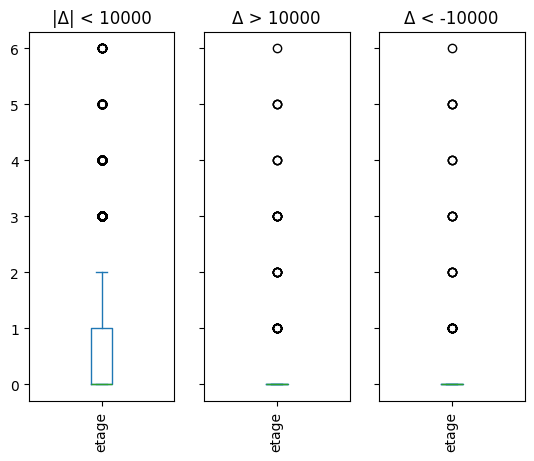



#### Variable  surface  ####
|delta_prediction| < 10000
count    4582.000000
mean       97.822567
std        40.809851
min        12.000000
25%        70.000000
50%        92.000000
75%       119.000000
max       320.000000
Name: surface, dtype: float64
delta_prediction > 10000
count    296.000000
mean     175.608108
std       66.850669
min       31.000000
25%      129.750000
50%      170.000000
75%      208.500000
max      420.000000
Name: surface, dtype: float64
delta_prediction < -10000
count    249.000000
mean     152.666667
std       66.533563
min       12.000000
25%      108.000000
50%      153.000000
75%      200.000000
max      330.000000
Name: surface, dtype: float64


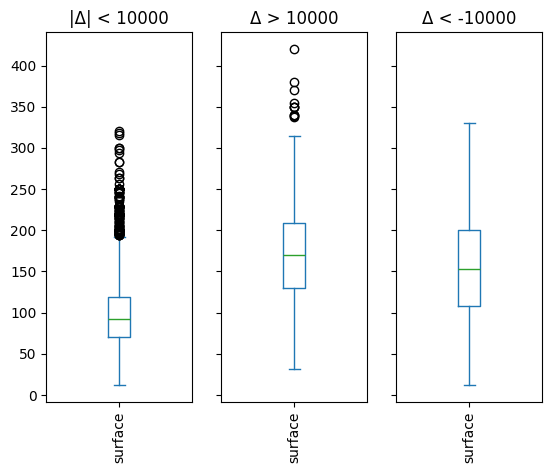



#### Variable  surface_terrain  ####
|delta_prediction| < 10000
count    1840.000000
mean      606.214049
std       418.436273
min         1.480000
25%       342.250000
50%       543.000000
75%       752.000000
max      2783.000000
Name: surface_terrain, dtype: float64
delta_prediction > 10000
count     211.000000
mean      905.730995
std       552.470218
min         9.000000
25%       568.500000
50%       800.000000
75%      1130.000000
max      2779.000000
Name: surface_terrain, dtype: float64
delta_prediction < -10000
count     167.000000
mean      766.909940
std       532.511403
min         4.610000
25%       453.000000
50%       639.000000
75%       970.000000
max      2750.000000
Name: surface_terrain, dtype: float64


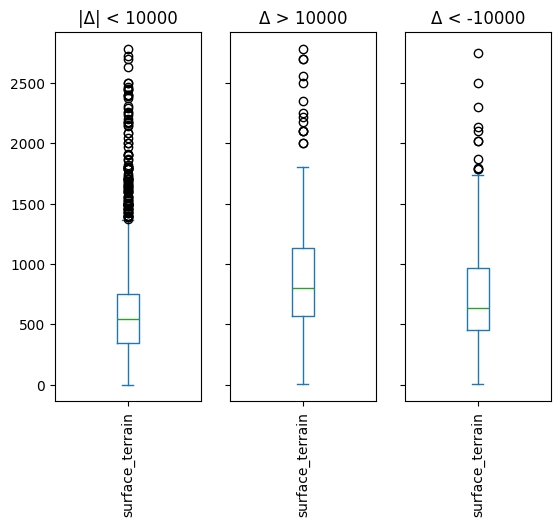



#### Variable  nb_pieces  ####
|delta_prediction| < 10000
count    4582.000000
mean        4.239633
std         1.578540
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: nb_pieces, dtype: float64
delta_prediction > 10000
count    296.000000
mean       6.361486
std        2.058732
min        1.000000
25%        5.000000
50%        6.000000
75%        7.250000
max       12.000000
Name: nb_pieces, dtype: float64
delta_prediction < -10000
count    249.000000
mean       5.863454
std        2.271277
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64


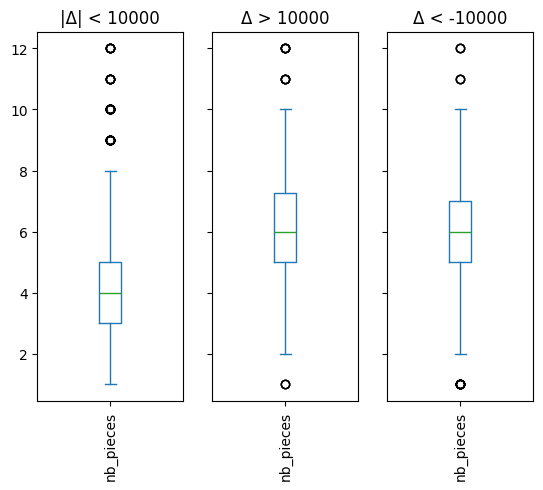



#### Variable  prix_maison  ####
|delta_prediction| < 10000
count        79.000000
mean     212025.430380
std       69508.786882
min      114500.000000
25%      140980.000000
50%      205500.000000
75%      250700.000000
max      410000.000000
Name: prix_maison, dtype: float64
delta_prediction > 10000
count         2.000000
mean     268005.000000
std       25448.773055
min      250010.000000
25%      259007.500000
50%      268005.000000
75%      277002.500000
max      286000.000000
Name: prix_maison, dtype: float64
delta_prediction < -10000
count         2.000000
mean     304617.000000
std       28589.741377
min      284401.000000
25%      294509.000000
50%      304617.000000
75%      314725.000000
max      324833.000000
Name: prix_maison, dtype: float64


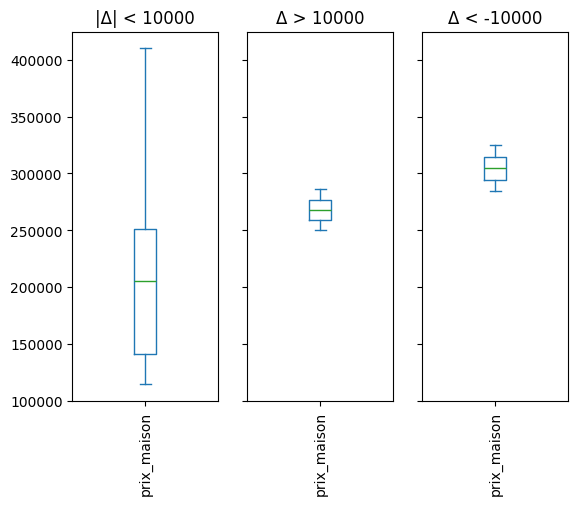



#### Variable  prix_terrain  ####
|delta_prediction| < 10000
count        79.000000
mean      93552.493671
std       52834.243444
min           1.000000
25%       62350.000000
50%       91000.000000
75%      121435.000000
max      320000.000000
Name: prix_terrain, dtype: float64
delta_prediction > 10000
count         2.000000
mean     127460.000000
std        3592.102448
min      124920.000000
25%      126190.000000
50%      127460.000000
75%      128730.000000
max      130000.000000
Name: prix_terrain, dtype: float64
delta_prediction < -10000
count         2.000000
mean     133875.000000
std       31996.581849
min      111250.000000
25%      122562.500000
50%      133875.000000
75%      145187.500000
max      156500.000000
Name: prix_terrain, dtype: float64


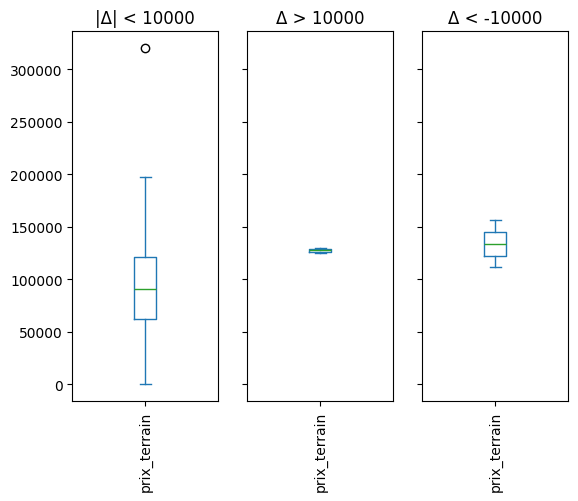



#### Variable  mensualiteFinance  ####
|delta_prediction| < 10000
count    4582.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: mensualiteFinance, dtype: float64
delta_prediction > 10000
count    296.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: mensualiteFinance, dtype: float64
delta_prediction < -10000
count    249.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: mensualiteFinance, dtype: float64


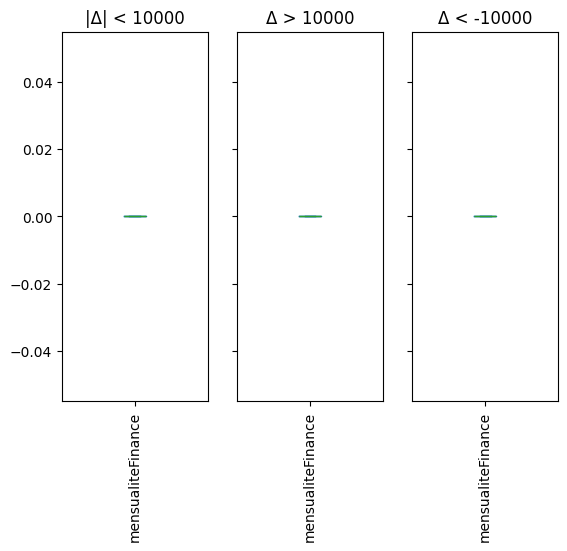



#### Variable  balcon  ####
|delta_prediction| < 10000
count    4582.000000
mean        0.160410
std         0.398945
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: balcon, dtype: float64
delta_prediction > 10000
count    296.000000
mean       0.121622
std        0.375620
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: balcon, dtype: float64
delta_prediction < -10000
count    249.000000
mean       0.092369
std        0.290130
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: balcon, dtype: float64


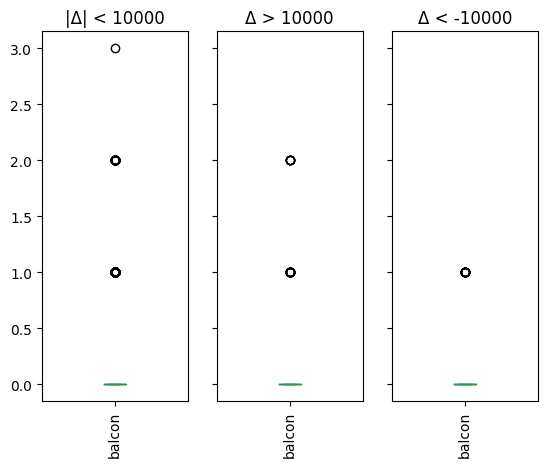



#### Variable  eau  ####
|delta_prediction| < 10000
count    4582.000000
mean        0.281318
std         0.515293
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         3.000000
Name: eau, dtype: float64
delta_prediction > 10000
count    296.000000
mean       0.466216
std        0.697847
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: eau, dtype: float64
delta_prediction < -10000
count    249.000000
mean       0.337349
std        0.621077
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: eau, dtype: float64


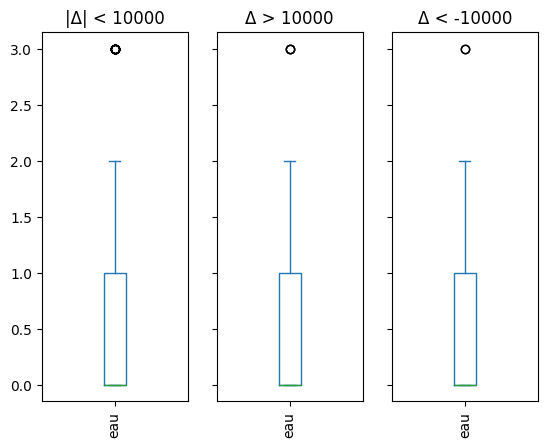



#### Variable  bain  ####
|delta_prediction| < 10000
count    4582.000000
mean        0.630292
std         0.597914
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: bain, dtype: float64
delta_prediction > 10000
count    296.000000
mean       0.864865
std        0.832791
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: bain, dtype: float64
delta_prediction < -10000
count    249.000000
mean       0.787149
std        0.792401
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: bain, dtype: float64


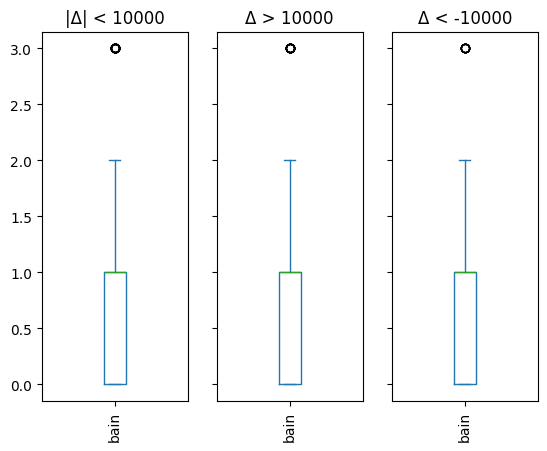



#### Variable  dpeC  ####
|delta_prediction| < 10000
count    2815.000000
mean      207.942458
std        98.972725
min         1.000000
25%       137.000000
50%       199.000000
75%       266.000000
max       689.000000
Name: dpeC, dtype: float64
delta_prediction > 10000
count    208.000000
mean     199.085000
std       93.068565
min        3.000000
25%      140.750000
50%      195.000000
75%      250.000000
max      541.000000
Name: dpeC, dtype: float64
delta_prediction < -10000
count    159.000000
mean     218.928302
std      117.354679
min        6.000000
25%      144.000000
50%      193.000000
75%      278.500000
max      636.000000
Name: dpeC, dtype: float64


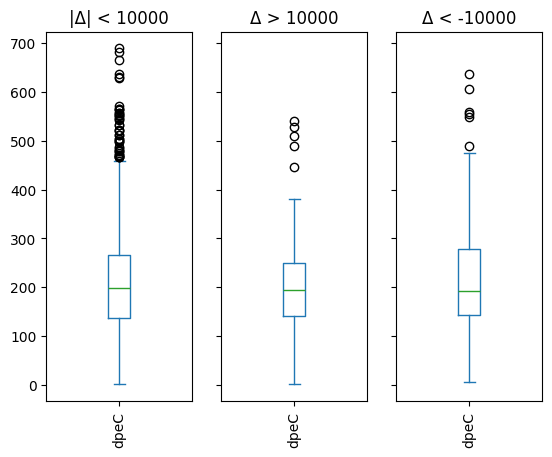



#### Variable  mapCoordonneesLatitude  ####
|delta_prediction| < 10000
count    4582.000000
mean       47.808353
std         0.181576
min        47.448620
25%        47.672677
50%        47.762480
75%        47.940242
max        48.283840
Name: mapCoordonneesLatitude, dtype: float64
delta_prediction > 10000
count    296.000000
mean      47.785337
std        0.192981
min       47.429600
25%       47.623900
50%       47.745375
75%       47.936372
max       48.271310
Name: mapCoordonneesLatitude, dtype: float64
delta_prediction < -10000
count    249.000000
mean      47.792836
std        0.183731
min       47.482490
25%       47.650070
50%       47.750440
75%       47.908170
max       48.247670
Name: mapCoordonneesLatitude, dtype: float64


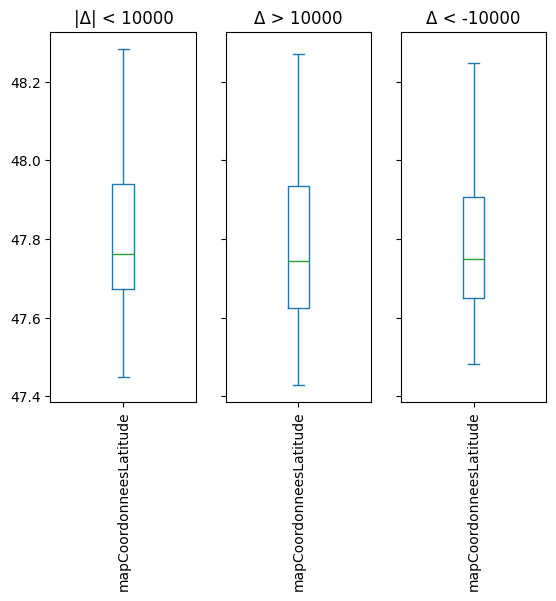



#### Variable  mapCoordonneesLongitude  ####
|delta_prediction| < 10000
count    4582.000000
mean        7.342067
std         0.126864
min         6.904880
25%         7.278717
50%         7.342180
75%         7.407045
max         7.588670
Name: mapCoordonneesLongitude, dtype: float64
delta_prediction > 10000
count    296.000000
mean       7.330671
std        0.139645
min        6.903600
25%        7.240375
50%        7.337375
75%        7.415460
max        7.592830
Name: mapCoordonneesLongitude, dtype: float64
delta_prediction < -10000
count    249.000000
mean       7.321412
std        0.150798
min        6.904780
25%        7.236810
50%        7.342790
75%        7.399580
max        7.588610
Name: mapCoordonneesLongitude, dtype: float64


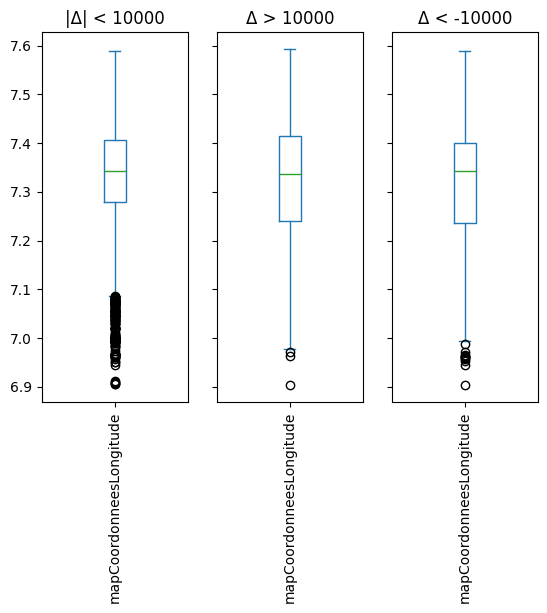



#### Variable  nb_etages  ####
|delta_prediction| < 10000
count    2506.000000
mean        2.522745
std         1.395917
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: nb_etages, dtype: float64
delta_prediction > 10000
count    147.000000
mean       2.081633
std        1.030429
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: nb_etages, dtype: float64
delta_prediction < -10000
count    114.000000
mean       2.228070
std        1.039359
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: nb_etages, dtype: float64


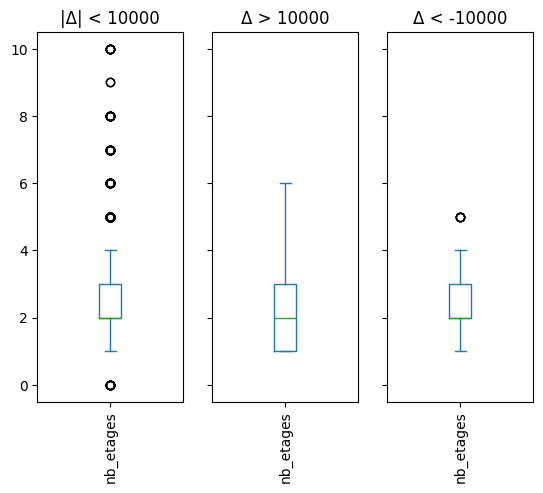



#### Variable  places_parking  ####
|delta_prediction| < 10000
count    1695.000000
mean        1.821829
std         1.178866
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: places_parking, dtype: float64
delta_prediction > 10000
count    137.000000
mean       2.379562
std        1.312448
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: places_parking, dtype: float64
delta_prediction < -10000
count    91.000000
mean      2.637363
std       1.567138
min       0.000000
25%       1.500000
50%       2.000000
75%       4.000000
max       7.000000
Name: places_parking, dtype: float64


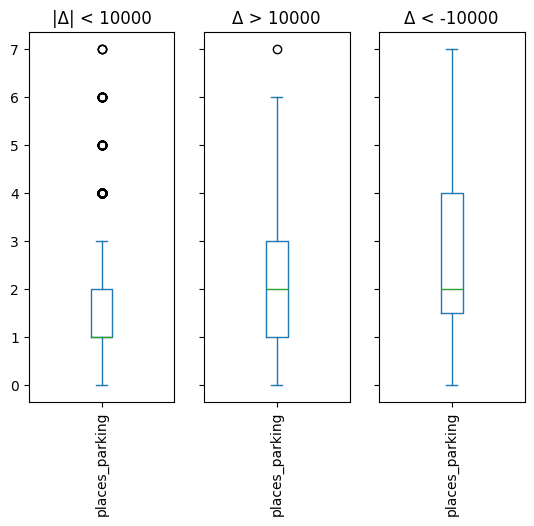



#### Variable  annee_construction  ####
|delta_prediction| < 10000
count    1580.00000
mean     1975.14557
std        42.45357
min      1749.00000
25%      1955.00000
50%      1980.00000
75%      2008.00000
max      2025.00000
Name: annee_construction, dtype: float64
delta_prediction > 10000
count     122.000000
mean     1965.237705
std        52.284671
min      1800.000000
25%      1947.250000
50%      1978.500000
75%      2005.000000
max      2022.000000
Name: annee_construction, dtype: float64
delta_prediction < -10000
count      97.000000
mean     1959.309278
std        50.487697
min      1750.000000
25%      1930.000000
50%      1970.000000
75%      2001.000000
max      2022.000000
Name: annee_construction, dtype: float64


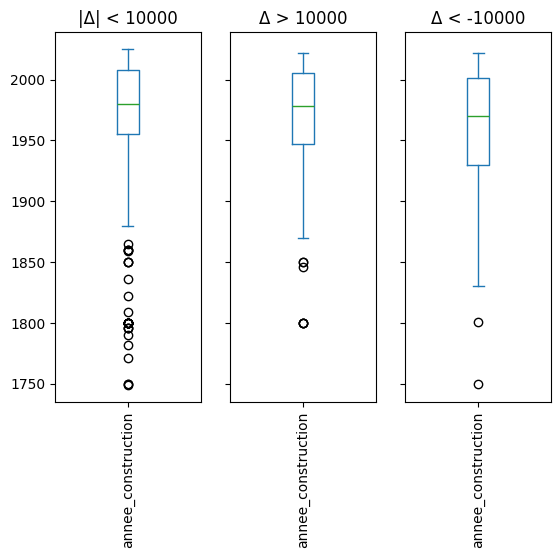



#### Variable  nb_toilettes  ####
|delta_prediction| < 10000
count    2587.000000
mean        1.398531
std         0.588664
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: nb_toilettes, dtype: float64
delta_prediction > 10000
count    179.000000
mean       2.061453
std        0.780104
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: nb_toilettes, dtype: float64
delta_prediction < -10000
count    143.000000
mean       1.832168
std        0.768994
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: nb_toilettes, dtype: float64


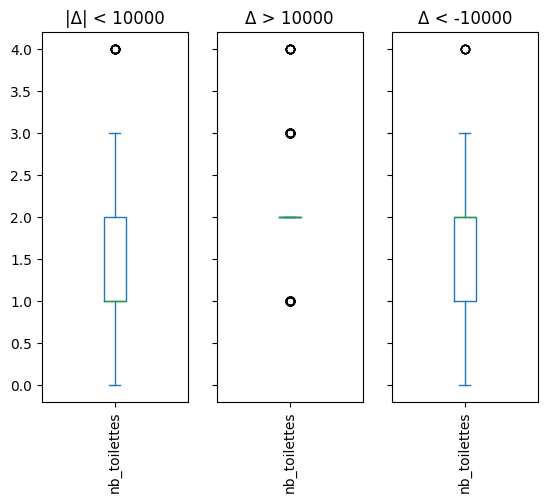



#### Variable  nb_terraces  ####
|delta_prediction| < 10000
count    675.000000
mean       1.000000
std        0.478003
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: nb_terraces, dtype: float64
delta_prediction > 10000
count    58.000000
mean      1.137931
std       0.544455
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: nb_terraces, dtype: float64
delta_prediction < -10000
count    36.000000
mean      1.194444
std       0.576663
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: nb_terraces, dtype: float64


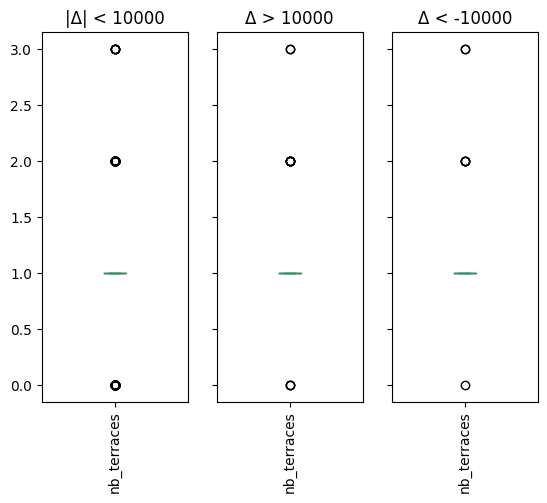



#### Variable  surface_balcon  ####
|delta_prediction| < 10000
count    123.000000
mean      10.983740
std        7.612526
min        2.000000
25%        7.000000
50%       10.000000
75%       13.000000
max       71.000000
Name: surface_balcon, dtype: float64
delta_prediction > 10000
count     1.0
mean     54.0
std       NaN
min      54.0
25%      54.0
50%      54.0
75%      54.0
max      54.0
Name: surface_balcon, dtype: float64
delta_prediction < -10000
count     4.000000
mean     11.500000
std       6.027714
min       6.000000
25%       8.250000
50%      10.000000
75%      13.250000
max      20.000000
Name: surface_balcon, dtype: float64


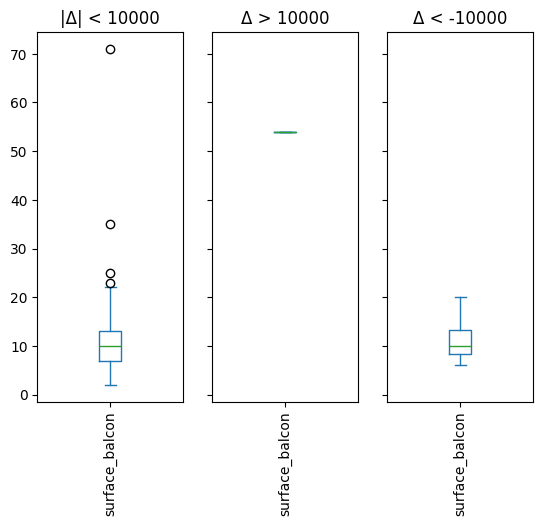



#### Variable  nb_logements_copro  ####
|delta_prediction| < 10000
count    1313.000000
mean       38.845392
std        44.222825
min         0.000000
25%         9.000000
50%        21.000000
75%        51.000000
max       232.000000
Name: nb_logements_copro, dtype: float64
delta_prediction > 10000
count     35.000000
mean      36.171429
std       51.430413
min        2.000000
25%        5.000000
50%       14.000000
75%       36.500000
max      193.000000
Name: nb_logements_copro, dtype: float64
delta_prediction < -10000
count     22.000000
mean      33.909091
std       52.258432
min        2.000000
25%        5.250000
50%       12.000000
75%       26.750000
max      166.000000
Name: nb_logements_copro, dtype: float64


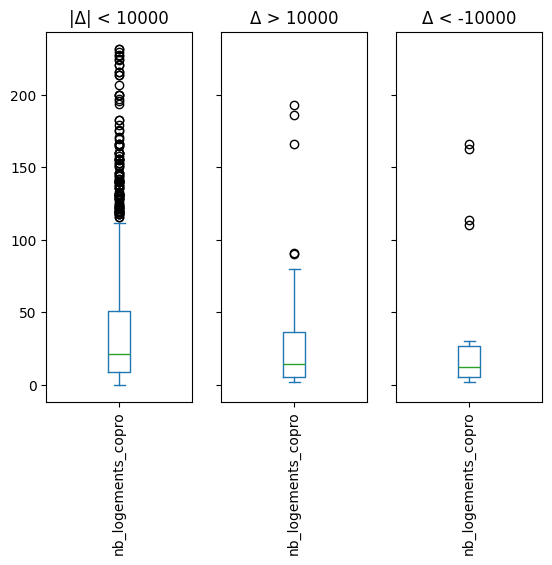



#### Variable  charges_copro  ####
|delta_prediction| < 10000
count    1202.000000
mean     1284.434185
std       912.691431
min         0.000000
25%       600.000000
50%      1154.000000
75%      1830.750000
max      4560.000000
Name: charges_copro, dtype: float64
delta_prediction > 10000
count      26.000000
mean     1659.218462
std      1322.478997
min         0.000000
25%       435.750000
50%      1460.000000
75%      2584.000000
max      3900.000000
Name: charges_copro, dtype: float64
delta_prediction < -10000
count      21.000000
mean     1530.668571
std      1020.625980
min         0.000000
25%       800.000000
50%      1520.040000
75%      1850.000000
max      3900.000000
Name: charges_copro, dtype: float64


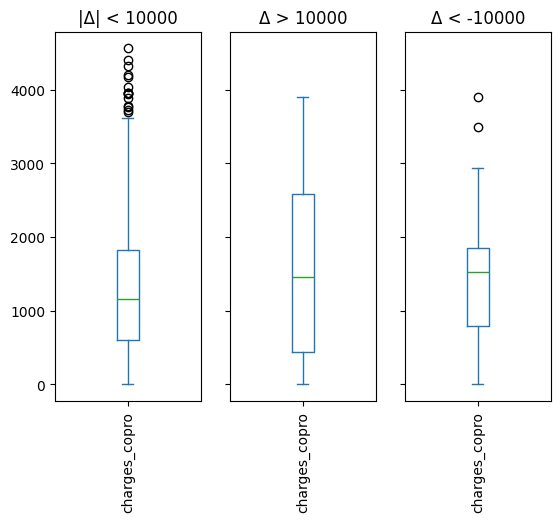



#### Variable  duree_int  ####
|delta_prediction| < 10000
count    4340.000000
mean     -123.901152
std       393.063478
min     -1125.000000
25%         6.000000
50%        22.000000
75%        75.000000
max       568.000000
Name: duree_int, dtype: float64
delta_prediction > 10000
count     282.000000
mean      -75.843972
std       354.605867
min     -1062.000000
25%         9.000000
50%        39.000000
75%       105.250000
max       562.000000
Name: duree_int, dtype: float64
delta_prediction < -10000
count     232.000000
mean      -86.887931
std       377.623814
min     -1070.000000
25%         8.000000
50%        35.000000
75%        98.000000
max       425.000000
Name: duree_int, dtype: float64


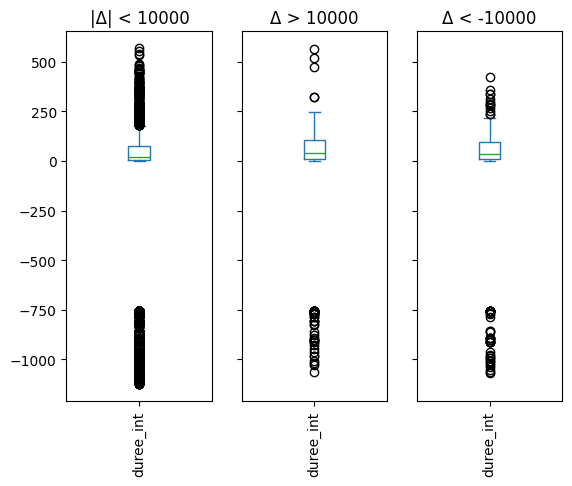



#### Variable  INSEE_COM  ####
|delta_prediction| < 10000
count     4582.000000
mean     68192.059363
std        106.230055
min      68001.000000
25%      68082.000000
50%      68216.000000
75%      68278.000000
max      68386.000000
Name: INSEE_COM, dtype: float64
delta_prediction > 10000
count      296.000000
mean     68193.841216
std        109.176261
min      68004.000000
25%      68098.750000
50%      68199.000000
75%      68295.500000
max      68384.000000
Name: INSEE_COM, dtype: float64
delta_prediction < -10000
count      249.000000
mean     68198.638554
std        107.160858
min      68001.000000
25%      68120.000000
50%      68224.000000
75%      68295.000000
max      68386.000000
Name: INSEE_COM, dtype: float64


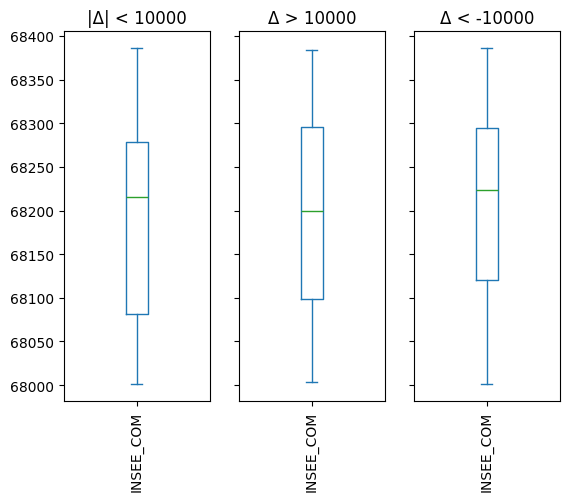



#### Variable  IRIS  ####
|delta_prediction| < 10000
count    4582.000000
mean      170.259494
std       332.659131
min         0.000000
25%         0.000000
50%       101.000000
75%       104.000000
max      1802.000000
Name: IRIS, dtype: float64
delta_prediction > 10000
count     296.000000
mean      112.064189
std       269.325471
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max      1703.000000
Name: IRIS, dtype: float64
delta_prediction < -10000
count     249.000000
mean      136.285141
std       281.986593
min         0.000000
25%         0.000000
50%         0.000000
75%       102.000000
max      1701.000000
Name: IRIS, dtype: float64


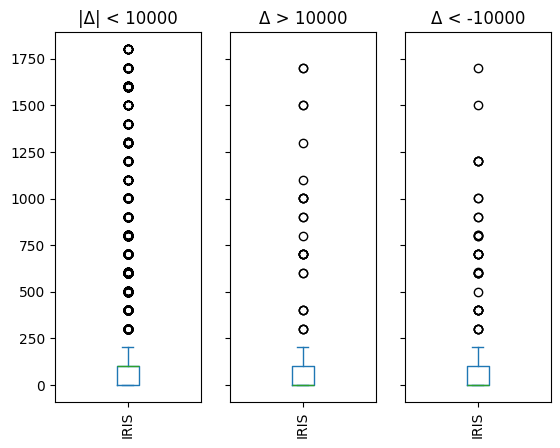



#### Variable  CODE_IRIS  ####
|delta_prediction| < 10000
count    4.582000e+03
mean     6.819208e+08
std      1.062286e+06
min      6.800100e+08
25%      6.808200e+08
50%      6.821600e+08
75%      6.827801e+08
max      6.838600e+08
Name: CODE_IRIS, dtype: float64
delta_prediction > 10000
count    2.960000e+02
mean     6.819385e+08
std      1.091768e+06
min      6.800401e+08
25%      6.809875e+08
50%      6.819900e+08
75%      6.829550e+08
max      6.838400e+08
Name: CODE_IRIS, dtype: float64
delta_prediction < -10000
count    2.490000e+02
mean     6.819865e+08
std      1.071590e+06
min      6.800100e+08
25%      6.812000e+08
50%      6.822401e+08
75%      6.829500e+08
max      6.838600e+08
Name: CODE_IRIS, dtype: float64


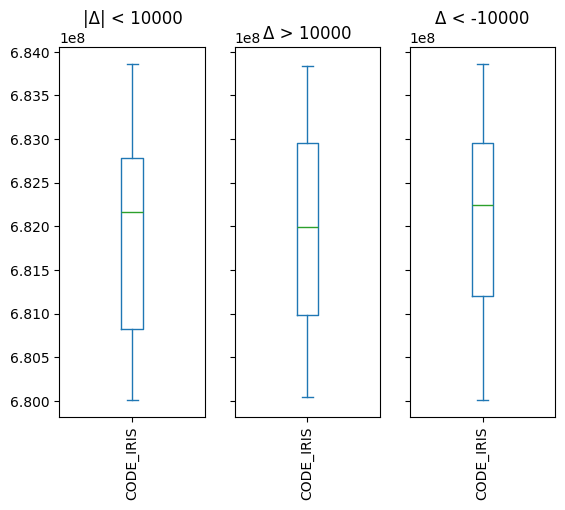



#### Variable  GRD_QUART  ####
|delta_prediction| < 10000
count    4.582000e+03
mean     6.819206e+06
std      1.062301e+04
min      6.800100e+06
25%      6.808200e+06
50%      6.821600e+06
75%      6.827801e+06
max      6.838600e+06
Name: GRD_QUART, dtype: float64
delta_prediction > 10000
count    2.960000e+02
mean     6.819385e+06
std      1.091766e+04
min      6.800401e+06
25%      6.809875e+06
50%      6.819900e+06
75%      6.829550e+06
max      6.838400e+06
Name: GRD_QUART, dtype: float64
delta_prediction < -10000
count    2.490000e+02
mean     6.819864e+06
std      1.071608e+04
min      6.800100e+06
25%      6.812000e+06
50%      6.822401e+06
75%      6.829500e+06
max      6.838600e+06
Name: GRD_QUART, dtype: float64


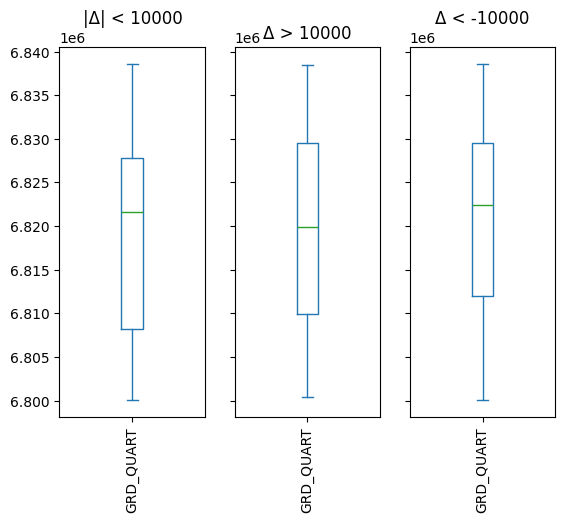



#### Variable  UU2010  ####
|delta_prediction| < 10000
count     4582.000000
mean     68371.154299
std        268.372607
min      68000.000000
25%      68113.000000
50%      68403.000000
75%      68701.000000
max      68701.000000
Name: UU2010, dtype: float64
delta_prediction > 10000
count      296.000000
mean     68303.422297
std        271.419022
min      68000.000000
25%      68000.000000
50%      68254.000000
75%      68501.000000
max      68701.000000
Name: UU2010, dtype: float64
delta_prediction < -10000
count      249.000000
mean     68312.301205
std        264.342203
min      68000.000000
25%      68000.000000
50%      68301.000000
75%      68501.000000
max      68701.000000
Name: UU2010, dtype: float64


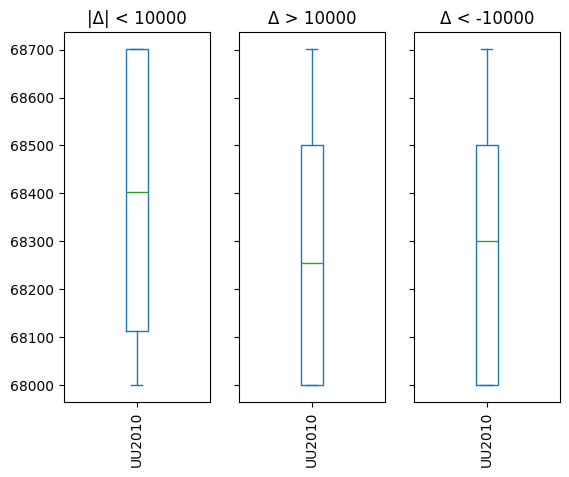



#### Variable  REG  ####
|delta_prediction| < 10000
count    4582.0
mean       44.0
std         0.0
min        44.0
25%        44.0
50%        44.0
75%        44.0
max        44.0
Name: REG, dtype: float64
delta_prediction > 10000
count    296.0
mean      44.0
std        0.0
min       44.0
25%       44.0
50%       44.0
75%       44.0
max       44.0
Name: REG, dtype: float64
delta_prediction < -10000
count    249.0
mean      44.0
std        0.0
min       44.0
25%       44.0
50%       44.0
75%       44.0
max       44.0
Name: REG, dtype: float64


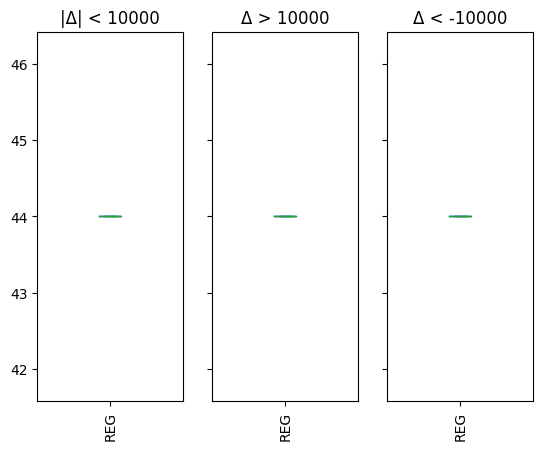



#### Variable  DEP  ####
|delta_prediction| < 10000
count    4582.0
mean       68.0
std         0.0
min        68.0
25%        68.0
50%        68.0
75%        68.0
max        68.0
Name: DEP, dtype: float64
delta_prediction > 10000
count    296.0
mean      68.0
std        0.0
min       68.0
25%       68.0
50%       68.0
75%       68.0
max       68.0
Name: DEP, dtype: float64
delta_prediction < -10000
count    249.0
mean      68.0
std        0.0
min       68.0
25%       68.0
50%       68.0
75%       68.0
max       68.0
Name: DEP, dtype: float64


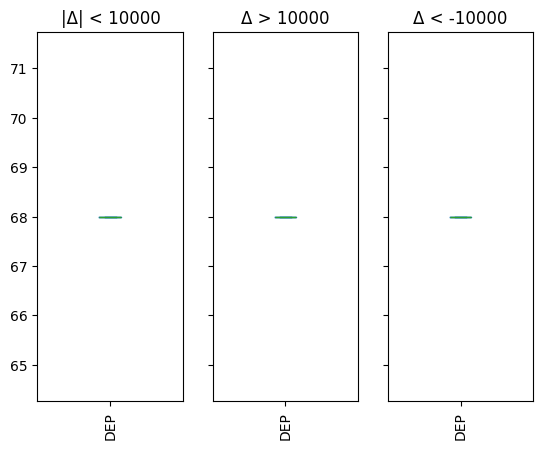



#### Variable  loyer_m2_median_n6  ####
|delta_prediction| < 10000
count    3026.000000
mean       10.804342
std         2.013234
min         4.780000
25%         9.500000
50%        10.560000
75%        11.950000
max        23.120000
Name: loyer_m2_median_n6, dtype: float64
delta_prediction > 10000
count    103.000000
mean      10.430097
std        2.162258
min        5.410000
25%        8.860000
50%       10.200000
75%       12.020000
max       17.570000
Name: loyer_m2_median_n6, dtype: float64
delta_prediction < -10000
count    99.000000
mean     11.334444
std       2.726327
min       6.470000
25%       9.065000
50%      11.330000
75%      13.320000
max      18.750000
Name: loyer_m2_median_n6, dtype: float64


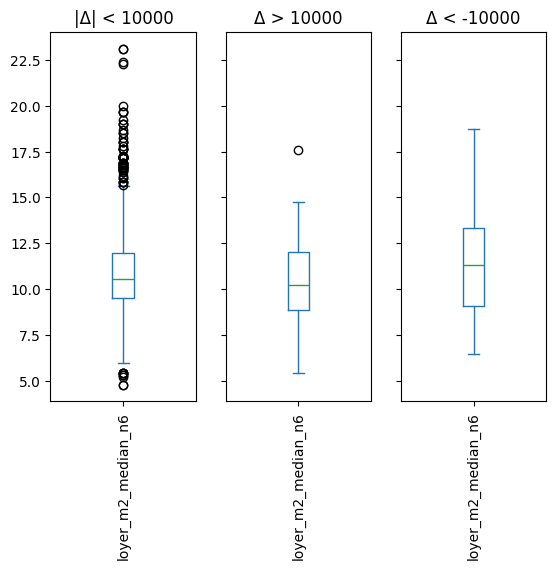



#### Variable  nb_log_n6  ####
|delta_prediction| < 10000
count    3026.000000
mean       17.091870
std        29.112506
min         1.000000
25%         2.000000
50%         6.000000
75%        19.000000
max       212.000000
Name: nb_log_n6, dtype: float64
delta_prediction > 10000
count    103.000000
mean       9.485437
std       25.164504
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      212.000000
Name: nb_log_n6, dtype: float64
delta_prediction < -10000
count     99.00000
mean       9.69697
std       19.24199
min        1.00000
25%        1.00000
50%        3.00000
75%       10.00000
max      137.00000
Name: nb_log_n6, dtype: float64


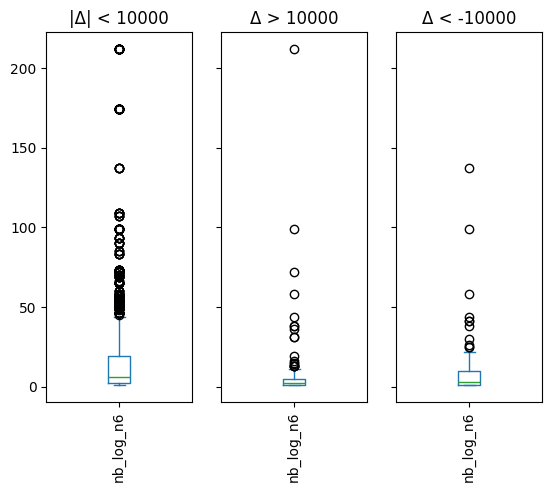



#### Variable  taux_rendement_n6  ####
|delta_prediction| < 10000
count    3026.000000
mean        0.055364
std         0.025182
min         0.020000
25%         0.039000
50%         0.048000
75%         0.064000
max         0.357000
Name: taux_rendement_n6, dtype: float64
delta_prediction > 10000
count    103.000000
mean       0.040447
std        0.020690
min        0.013000
25%        0.027000
50%        0.034000
75%        0.047500
max        0.123000
Name: taux_rendement_n6, dtype: float64
delta_prediction < -10000
count    99.000000
mean      0.053394
std       0.049430
min       0.018000
25%       0.027500
50%       0.039000
75%       0.053500
max       0.344000
Name: taux_rendement_n6, dtype: float64


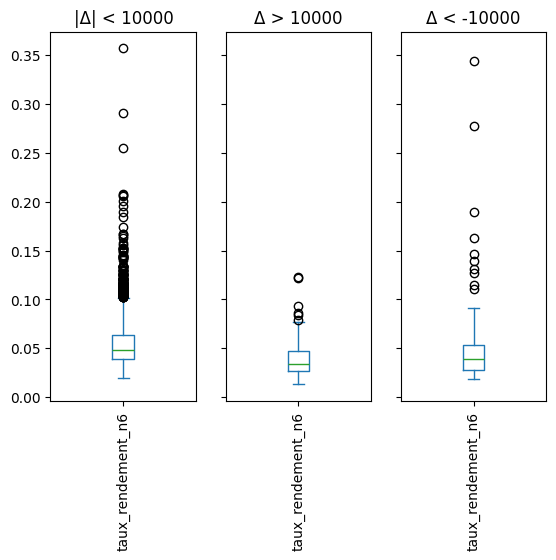



#### Variable  loyer_m2_median_n7  ####
|delta_prediction| < 10000
count    3388.000000
mean       10.665035
std         1.882436
min         4.780000
25%         9.440000
50%        10.460000
75%        11.810000
max        19.670000
Name: loyer_m2_median_n7, dtype: float64
delta_prediction > 10000
count    139.00000
mean       9.86741
std        2.18379
min        5.26000
25%        8.57000
50%        9.22000
75%       11.64000
max       17.57000
Name: loyer_m2_median_n7, dtype: float64
delta_prediction < -10000
count    129.000000
mean      10.851860
std        2.737125
min        6.310000
25%        9.050000
50%       10.340000
75%       13.160000
max       18.750000
Name: loyer_m2_median_n7, dtype: float64


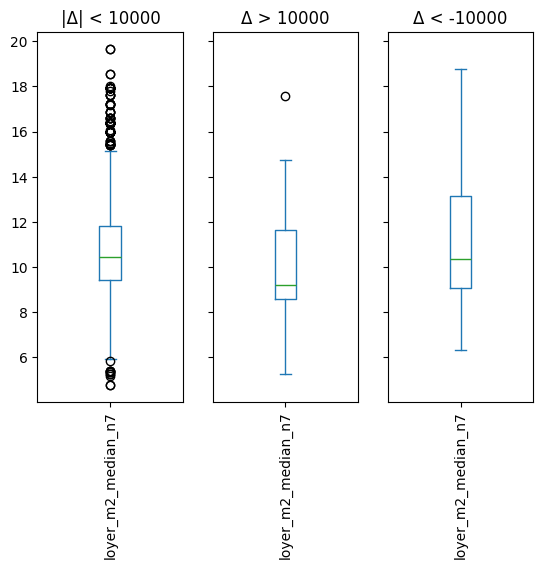



#### Variable  nb_log_n7  ####
|delta_prediction| < 10000
count    3388.000000
mean      146.749115
std       253.187161
min         1.000000
25%         3.000000
50%        16.000000
75%       149.000000
max       960.000000
Name: nb_log_n7, dtype: float64
delta_prediction > 10000
count    139.000000
mean      51.294964
std      139.531797
min        1.000000
25%        1.000000
50%        3.000000
75%       11.000000
max      839.000000
Name: nb_log_n7, dtype: float64
delta_prediction < -10000
count    129.000000
mean      79.643411
std      188.838506
min        1.000000
25%        1.000000
50%        3.000000
75%       14.000000
max      839.000000
Name: nb_log_n7, dtype: float64


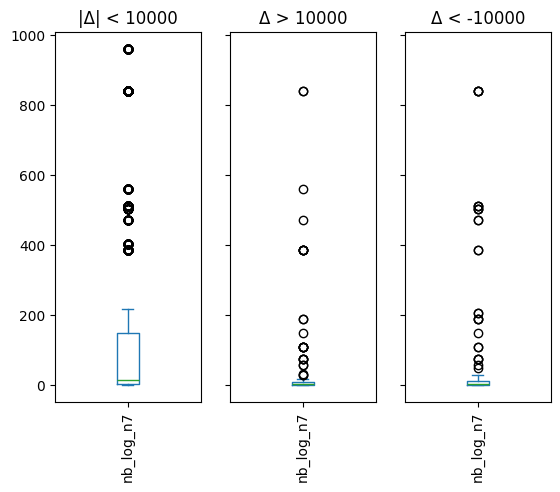



#### Variable  taux_rendement_n7  ####
|delta_prediction| < 10000
count    3388.000000
mean        0.055366
std         0.024840
min         0.018000
25%         0.039000
50%         0.048000
75%         0.065000
max         0.357000
Name: taux_rendement_n7, dtype: float64
delta_prediction > 10000
count    139.000000
mean       0.040446
std        0.020858
min        0.010000
25%        0.026000
50%        0.035000
75%        0.048500
max        0.135000
Name: taux_rendement_n7, dtype: float64
delta_prediction < -10000
count    129.00000
mean       0.05369
std        0.04764
min        0.01200
25%        0.02900
50%        0.04100
75%        0.05700
max        0.38400
Name: taux_rendement_n7, dtype: float64


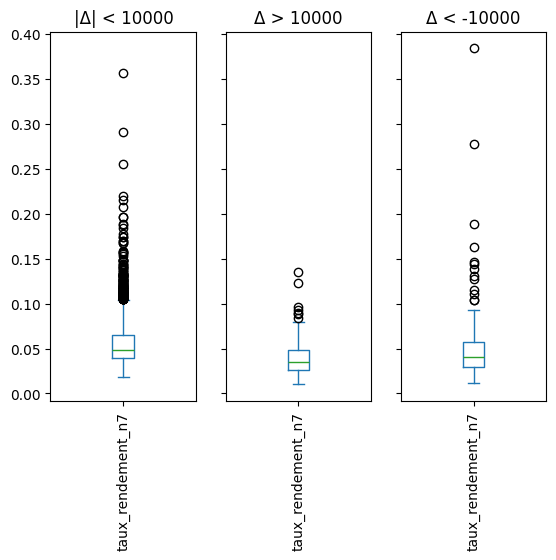



#### Variable  prix_m2_vente  ####
|delta_prediction| < 10000
count    4582.000000
mean     2608.350172
std       903.675483
min       471.830000
25%      1942.582500
50%      2619.965000
75%      3240.082500
max      6780.820000
Name: prix_m2_vente, dtype: float64
delta_prediction > 10000
count     296.000000
mean     3027.020980
std      1412.057903
min       583.940000
25%      1886.250000
50%      2795.590000
75%      3916.410000
max      7626.510000
Name: prix_m2_vente, dtype: float64
delta_prediction < -10000
count     249.000000
mean     2777.668353
std      1522.638483
min        96.670000
25%      1458.330000
50%      2600.000000
75%      3826.530000
max      7800.000000
Name: prix_m2_vente, dtype: float64


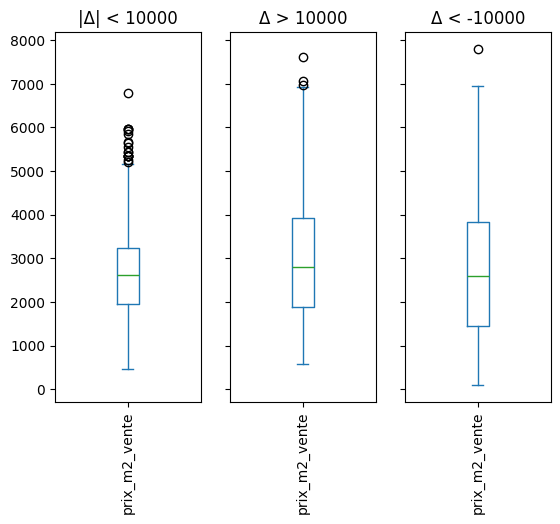

In [19]:
for col in df_tree_diff.select_dtypes(exclude=['object']).columns[:]:
    if col != 'delta_prediction' and col != 'prix_bien_y':
        plt.Figure()
        print("\n\n#### Variable ", col, " ####")
        print("|delta_prediction| < 10000")
        print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].describe())
        print("delta_prediction > 10000")
        print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].describe())
        print("delta_prediction < -10000")
        print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].describe())
        ax1 = plt.subplot(131)
        df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].plot(kind='box')
        plt.title("|Δ| < 10000")
        plt.xticks(rotation=90)
        ax2 = plt.subplot(132, sharey=ax1)
        df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].plot(kind='box', )
        plt.title("Δ > 10000")
        plt.xticks(rotation=90)
        ax3 = plt.subplot(133, sharey=ax1)
        df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].plot(kind='box', )
        plt.title("Δ < -10000")
        plt.xticks(rotation=90)
        plt.show()


On note sur les mauvaises prédictions, en comparaison aux bonnes prédictions, une distribution plus élevée sur les features suivantes :
* surface : P50 à 92 vs 166 sur les mauvaises prédiction
* surface_terrain : P50 à 543 vs 750 sur les mauvaises prédiction (! beaucoup de NaN)
* nb_pieces : P50 à 4 vs 6 sur les mauvaises prédictions

## 16.3) Variables identifié



#### Variable  typedebien_lite  ####
|delta_prediction| < 10000
typedebien_lite
a    2384
m    2198
Name: count, dtype: int64

delta_prediction > 10000
typedebien_lite
m    238
a     58
Name: count, dtype: int64

delta_prediction < -10000
typedebien_lite
m    189
a     60
Name: count, dtype: int64


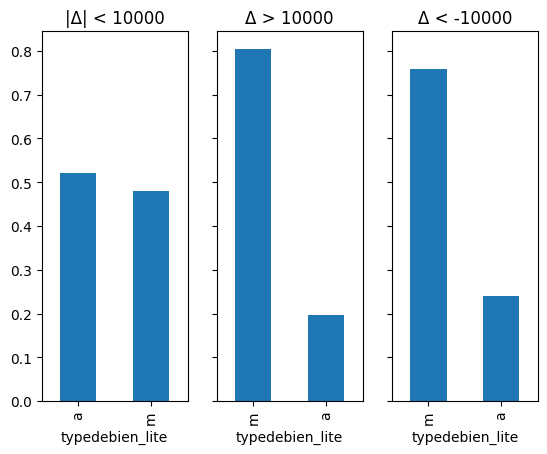

In [22]:
for col in ['typedebien_lite']:
    plt.Figure()
    print("\n\n#### Variable ", col, " ####")
    print("|delta_prediction| < 10000")
    print(df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts())
    print("\ndelta_prediction > 10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts())
    print("\ndelta_prediction < -10000")
    print(df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts())
    ax1 = plt.subplot(131)
    df_tree_diff[np.abs(df_tree_diff['delta_prediction']) <= 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("|Δ| < 10000")
    plt.xticks(rotation=90)
    ax2 = plt.subplot(132, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] > 10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ > 10000")
    plt.xticks(rotation=90)
    ax3 = plt.subplot(133, sharey=ax1)
    df_tree_diff[df_tree_diff['delta_prediction'] < -10000][col].value_counts(dropna=False, normalize=True).plot(kind='bar')
    plt.title("Δ < -10000")
    plt.xticks(rotation=90)
    plt.show()




#### Variable  surface  ####
|delta_prediction| < 10000
count    4582.000000
mean       97.822567
std        40.809851
min        12.000000
25%        70.000000
50%        92.000000
75%       119.000000
max       320.000000
Name: surface, dtype: float64
delta_prediction > 10000
count    296.000000
mean     175.608108
std       66.850669
min       31.000000
25%      129.750000
50%      170.000000
75%      208.500000
max      420.000000
Name: surface, dtype: float64
delta_prediction < -10000
count    249.000000
mean     152.666667
std       66.533563
min       12.000000
25%      108.000000
50%      153.000000
75%      200.000000
max      330.000000
Name: surface, dtype: float64


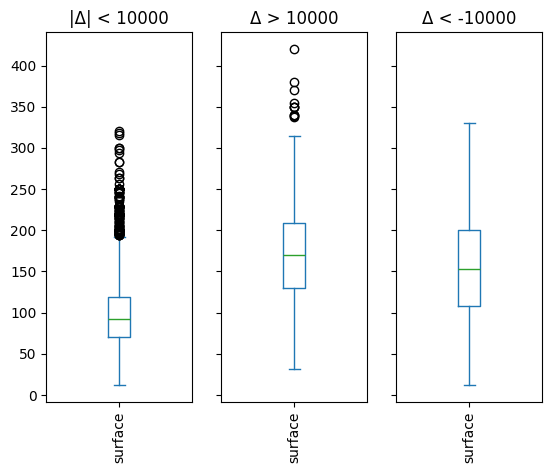



#### Variable  surface_terrain  ####
|delta_prediction| < 10000
count    4582.000000
mean      243.438204
std       398.272018
min         0.000000
25%         0.000000
50%         0.000000
75%       460.000000
max      2783.000000
Name: surface_terrain, dtype: float64
delta_prediction > 10000
count     296.000000
mean      645.639324
std       621.105693
min         0.000000
25%         0.000000
50%       611.000000
75%       994.000000
max      2779.000000
Name: surface_terrain, dtype: float64
delta_prediction < -10000
count     249.000000
mean      514.353253
std       565.893130
min         0.000000
25%         0.000000
50%       456.000000
75%       794.000000
max      2750.000000
Name: surface_terrain, dtype: float64


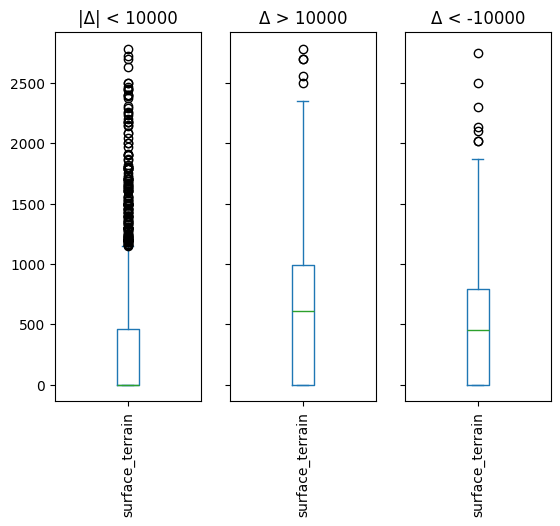



#### Variable  nb_pieces  ####
|delta_prediction| < 10000
count    4582.000000
mean        4.239633
std         1.578540
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        12.000000
Name: nb_pieces, dtype: float64
delta_prediction > 10000
count    296.000000
mean       6.361486
std        2.058732
min        1.000000
25%        5.000000
50%        6.000000
75%        7.250000
max       12.000000
Name: nb_pieces, dtype: float64
delta_prediction < -10000
count    249.000000
mean       5.863454
std        2.271277
min        1.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       12.000000
Name: nb_pieces, dtype: float64


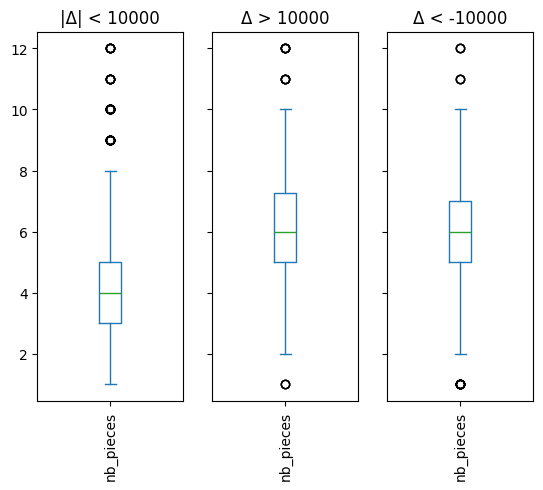

In [24]:
df_boxplot = df_tree_diff.fillna(0) # On remplie les NaN avec 0 dans le jeu de données initiale pour le boxplot
for col in ['surface', 'surface_terrain', 'nb_pieces']:
    if col != 'delta_prediction' and col != 'prix_bien_y':
        plt.Figure()
        print("\n\n#### Variable ", col, " ####")
        print("|delta_prediction| < 10000")
        print(df_boxplot[np.abs(df_boxplot['delta_prediction']) <= 10000][col].describe())
        print("delta_prediction > 10000")
        print(df_boxplot[df_boxplot['delta_prediction'] > 10000][col].describe())
        print("delta_prediction < -10000")
        print(df_boxplot[df_boxplot['delta_prediction'] < -10000][col].describe())
        ax1 = plt.subplot(131)
        df_boxplot[np.abs(df_boxplot['delta_prediction']) <= 10000][col].plot(kind='box')
        plt.title("|Δ| < 10000")
        plt.xticks(rotation=90)
        ax2 = plt.subplot(132, sharey=ax1)
        df_boxplot[df_boxplot['delta_prediction'] > 10000][col].plot(kind='box', )
        plt.title("Δ > 10000")
        plt.xticks(rotation=90)
        ax3 = plt.subplot(133, sharey=ax1)
        df_boxplot[df_boxplot['delta_prediction'] < -10000][col].plot(kind='box', )
        plt.title("Δ < -10000")
        plt.xticks(rotation=90)
        plt.show()


## 16.4) Longitude / Latitude

In [15]:
# --- Calculs de base
lat_long_mean = [df_tree_diff['mapCoordonneesLatitude'].mean(),
                 df_tree_diff['mapCoordonneesLongitude'].mean()]
min_lat = df_tree_diff['mapCoordonneesLatitude'].min()
max_lat = df_tree_diff['mapCoordonneesLatitude'].max()
min_lon = df_tree_diff['mapCoordonneesLongitude'].min()
max_lon = df_tree_diff['mapCoordonneesLongitude'].max()

# --- Seuils
low_thr = -10000
high_thr = 10000

# --- Comptages (avec priorités)
n_mid = ((df_tree_diff['delta_prediction'] >= low_thr) & (df_tree_diff['delta_prediction'] <= high_thr)).sum()
n_low = (df_tree_diff['delta_prediction'] < low_thr).sum()
n_high = (df_tree_diff['delta_prediction'] > high_thr).sum()

label_low = f"Delta (-∞ ; {low_thr}) | n={n_low}"
label_mid = f"Delta [{low_thr} ; {high_thr}] | n={n_mid}"
label_high = f"Delta ({high_thr} ; +∞) | n={n_high}"

# --- Couleurs
color_low = "#de2d26"
color_mid = "#3182bd"
color_high = "#de2d26"

# --- Carte
m = folium.Map(
    location=lat_long_mean,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# --- Groupes
groupes = {
    label_low: folium.FeatureGroup(name=label_low).add_to(m),
    label_mid: folium.FeatureGroup(name=label_mid).add_to(m),
    label_high: folium.FeatureGroup(name=label_high).add_to(m)
}

# --- Ajout des marqueurs
for index, row in df_tree_diff.iterrows():
    val = row['delta_prediction']
    lat = row['mapCoordonneesLatitude']
    lon = row['mapCoordonneesLongitude']

    # Priorité : groupe central d'abord
    if low_thr <= val <= high_thr:
        groupe = label_mid
        couleur = color_mid
    elif val < low_thr:
        groupe = label_low
        couleur = color_low
    else:
        groupe = label_high
        couleur = color_high

    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        opacity=1,
        fill_color=couleur,
        color=couleur,
        popup=f"Delta prediction: {val}"
    ).add_to(groupes[groupe])

LayerControl().add_to(m)

m